# #### Importing all libraries

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

#### Preprocessing

#### Functions to fetch Raw Data

In [ ]:
def get_acc_data(folder_path):
    '''
    ACC.csv
    Data from 3-axis accelerometer sensor.
    The accelerometer is configured to measure acceleration in the range [-2g, 2g].
    Therefore the unit in this file is 1/64g.
    Data from x, y, and z axis are respectively in first, second, and third column.

    The first row is the initial time of the session expressed as unix timestamp in UTC.
    The second row is the sample rate expressed in Hz.
    '''

    filename = os.path.join(folder_path, 'ACC.csv')


    # Load the CSV file into a DataFrame
    df = pd.read_csv(filename, header=None)

    # Get the first two rows of the DataFrame
    index_values = df.iloc[:2,:].values
    # Convert the first row to a datetime index
    index = pd.to_datetime(index_values[0], unit='s')

    # Get the sample rate from the second row
    sample_rate = index_values[1,0]

    data = df.iloc[2:,:]

    # Convert data to float type
    data = data.astype(float)

    # Create DatetimeIndex
    time_index = pd.date_range(start=index[0], periods=len(data), freq=f'{sample_rate:.0f}S')

    # Set DatetimeIndex as index of DataFrame
    data.index = time_index

    # Convert from units of 1/64g to units of g
    data = data / 64.0
    data.columns = [['acc_x', 'acc_y', 'acc_z']]


    return data

acc_data = get_acc_data("/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data/S01")

In [ ]:
acc_data.head()

,acc_x,acc_y,acc_z
2022-02-07 09:27:41,-0.031250,0.671875,0.671875
2022-02-07 09:28:13,-0.031250,0.687500,0.718750
2022-02-07 09:28:45,0.031250,0.687500,0.734375
2022-02-07 09:29:17,0.046875,0.671875,0.687500
2022-02-07 09:29:49,0.015625,0.671875,0.703125


In [ ]:
import os
import pandas as pd

def get_acc_data(folder_path):
    '''
    ACC.csv
    Data from 3-axis accelerometer sensor.
    The accelerometer is configured to measure acceleration in the range [-2g, 2g].
    Therefore the unit in this file is 1/64g.
    Data from x, y, and z axis are respectively in first, second, and third column.

    The first row is the initial time of the session expressed as unix timestamp in UTC.
    The second row is the sample rate expressed in Hz.
    '''

    filename = os.path.join(folder_path, 'ACC.csv')

    # Load the CSV file into a DataFrame
    df = pd.read_csv(filename, header=None)

    # Extract initial time and sample rate
    initial_time = pd.to_datetime(df.iloc[0, 0], unit='s')
    sample_rate = float(df.iloc[1, 0])

    # Extract accelerometer data (x, y, z)
    data = df.iloc[2:, :3].astype(float)

    # Generate a proper time index based on sample rate
    time_interval = 1 / sample_rate
    time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{time_interval}S')

    # Set index and rename columns
    data.index = time_index
    data.columns = ['acc_x', 'acc_y', 'acc_z']

    # Convert from 1/64g to g
    data /= 64.0

    return data

# Example Usage
data = get_acc_data("/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data/S01")
print(data.head())


                               acc_x     acc_y     acc_z
2022-02-07 09:27:41.000000 -0.031250  0.671875  0.671875
2022-02-07 09:27:41.031250 -0.031250  0.687500  0.718750
2022-02-07 09:27:41.062500  0.031250  0.687500  0.734375
2022-02-07 09:27:41.093750  0.046875  0.671875  0.687500
2022-02-07 09:27:41.125000  0.015625  0.671875  0.703125


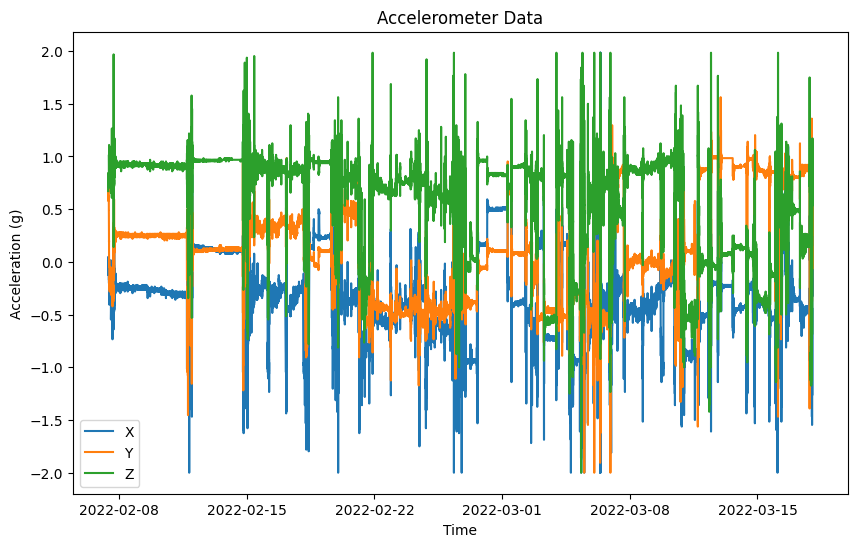

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
# Assuming 'acc_data' is a DataFrame, save it to a CSV file first
acc_data.to_csv('acc_data.csv', index=True)  # Save with index as a column named 'Timestamp'

# Then, read the CSV file, specifying the index column and header
# The error was here, specifying index_col=0 reads the first column of the csv file as the index.
# The parse_dates argument then has no column labelled 'Timestamp' to parse to a date format, hence the error
# By setting index_col='Unnamed: 0' we specify the column that actually contains the timestamp to be used as the index
data = pd.read_csv('acc_data.csv', index_col='Unnamed: 0', parse_dates=True)

# Alternatively, you can specify the index name when saving
# Unnecessary to repeat saving and reading of the csv file
# acc_data.to_csv('acc_data.csv', index=True, index_label='Timestamp')
# data = pd.read_csv('acc_data.csv', parse_dates=['Timestamp'], index_col='Timestamp')

# Now you can proceed with plotting
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['acc_x'], label='X')  # Assuming acc_x, acc_y, acc_z are your columns
plt.plot(data.index, data['acc_y'], label='Y')
plt.plot(data.index, data['acc_z'], label='Z')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Acceleration (g)')
plt.title('Accelerometer Data')
plt.show()

In [ ]:
# If your data doesn't have a DateTimeIndex, create one:
acc_data.index = pd.to_datetime(acc_data.index)

In [ ]:
! pip install neurokit2
import neurokit2 as nk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 48.4 MB/s eta 0:00:00


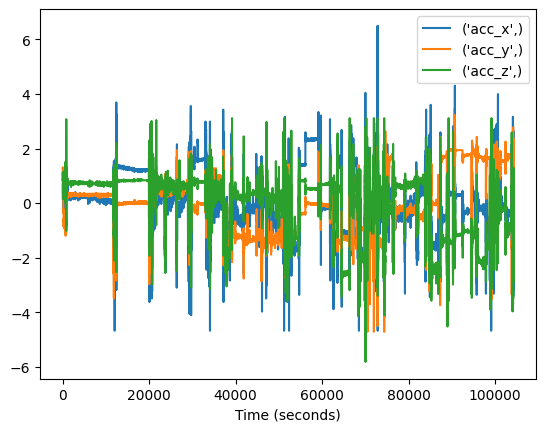

In [ ]:
# !pip install neurokit2
# import neurokit2 as nk
# import pandas as pd

# Convert DateTimeIndex to numeric index (in seconds)
numeric_index = (acc_data.index - acc_data.index[0]).total_seconds()
acc_data_numeric = acc_data.copy()  # Create a copy to avoid modifying the original
acc_data_numeric.index = numeric_index

# Now use the numeric index data for signal_plot
nk.signal_plot(acc_data_numeric, sampling_rate=32, standardize=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def get_bvp_data(folder_path):
    '''
    BVP.csv
    Data from photoplethysmograph.

    The first row is the initial time of the session expressed as unix timestamp in UTC.
    The second row is the sample rate expressed in Hz.
    '''

    filename = os.path.join(folder_path, 'BVP.csv')


    # Load the CSV file into a DataFrame
    df = pd.read_csv(filename, header=None)

    # Get the first two rows of the DataFrame
    index_values = df.iloc[:2,:].values
    # Convert the first row to a datetime index
    index = pd.to_datetime(index_values[0], unit='s')

    # Get the sample rate from the second row
    sample_rate = index_values[1,0]

    data = df.iloc[2:,:]

    # Convert data to float type
    data = data.astype(float)

    # Create DatetimeIndex
    time_index = pd.date_range(start=index[0], periods=len(data), freq=f'{sample_rate:.0f}S')

    # Set DatetimeIndex as index of DataFrame
    data.index = time_index
    data.columns = ['bvp']
    return data

bvp_data = get_bvp_data("/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data/S01")
bvp_data.head()

,bvp
2022-02-07 09:27:41,0.0
2022-02-07 09:28:45,0.0
2022-02-07 09:29:49,0.0
2022-02-07 09:30:53,0.0
2022-02-07 09:31:57,0.0


In [ ]:
def get_eda_data(folder_path):
    '''
    EDA.csv
    Data from the electrodermal activity sensor expressed as microsiemens (μS).

    The first row is the initial time of the session expressed as unix timestamp in UTC.
    The second row is the sample rate expressed in Hz.
    '''

    filename = os.path.join(folder_path, 'EDA.csv')


    # Load the CSV file into a DataFrame
    df = pd.read_csv(filename, header=None)

    # Get the first two rows of the DataFrame
    index_values = df.iloc[:2,:].values
    # Convert the first row to a datetime index
    index = pd.to_datetime(index_values[0], unit='s')

    # Get the sample rate from the second row
    sample_rate = index_values[1,0]

    data = df.iloc[2:,:]

    # Convert data to float type
    data = data.astype(float)

    # Create DatetimeIndex
    time_index = pd.date_range(start=index[0], periods=len(data), freq=f'{sample_rate:.0f}S')

    # Set DatetimeIndex as index of DataFrame
    data.index = time_index

    data.columns = ['eda']

    return data

eda_data = get_eda_data("/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data/S01")
eda_data.head()


,eda
2022-02-07 09:27:41,0.000000
2022-02-07 09:27:45,0.112750
2022-02-07 09:27:49,0.166563
2022-02-07 09:27:53,0.167844
2022-02-07 09:27:57,0.167844


In [ ]:
def get_hr_data(folder_path):
    '''
    HR.csv
    Average heart rate extracted from the BVP signal.The first row is the initial time of the session expressed as unix timestamp in UTC.
    The second row is the sample rate expressed in Hz.

    The first row is the initial time of the session expressed as unix timestamp in UTC.
    The second row is the sample rate expressed in Hz.
    '''

    filename = os.path.join(folder_path, 'HR.csv')


    # Load the CSV file into a DataFrame
    df = pd.read_csv(filename, header=None)

    # Get the first two rows of the DataFrame
    index_values = df.iloc[:2,:].values
    # Convert the first row to a datetime index
    index = pd.to_datetime(index_values[0], unit='s')

    # Get the sample rate from the second row
    sample_rate = index_values[1,0]

    data = df.iloc[2:,:]

    # Convert data to float type
    data = data.astype(float)

    # Create DatetimeIndex
    time_index = pd.date_range(start=index[0], periods=len(data), freq=f'{sample_rate:.0f}S')

    # Set DatetimeIndex as index of DataFrame
    data.index = time_index

    data.columns = ['hr']

    return data

hr_data=get_hr_data("/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data/S01")
hr_data.head()

,hr
2022-02-07 09:27:51,83.00
2022-02-07 09:27:52,83.00
2022-02-07 09:27:53,72.67
2022-02-07 09:27:54,87.00
2022-02-07 09:27:55,80.00


In [ ]:
def get_ibi_data(folder_path):
    '''
    IBI.csv
    Time between individuals heart beats extracted from the BVP signal.
    No sample rate is needed for this file.
    The first column is the time (respect to the initial time) of the detected inter-beat interval expressed in seconds (s).
    The second column is the duration in seconds (s) of the detected inter-beat interval (i.e., the distance in seconds from the previous beat).
    '''

    filename = os.path.join(folder_path, 'IBI.csv')

    # create a DataFrame from the data
    df = pd.read_csv(filename, header=None, names=['time', 'ibi'])

    index_values = df.iloc[:1,:].values

    # print(index_values)

    index = pd.to_datetime(index_values[0][0], unit='s')

    data = df.iloc[1:,:]

    # convert the time column to a datetime index -- need to floor to elliminate the millisecs
    data.index = pd.to_datetime(data['time'], unit='s', origin=index).dt.floor('s')

    # drop the original time column
    data.drop('time', axis=1, inplace=True)

    # data.columns = ['ibis']

    return data

ibi_data = get_ibi_data("/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data/S01")
ibi_data.head()

,ibi
time,
2022-02-07 09:28:16,0.890625
2022-02-07 09:28:17,0.859375
2022-02-07 09:28:18,0.953125
2022-02-07 09:28:19,0.890625
2022-02-07 09:28:20,0.859375


In [ ]:
def get_temp_data(folder_path):
    '''
    TEMP.csv
    Data from temperature sensor expressed degrees on the Celsius (°C) scale.

    The first column is the time (respect to the initial time) of the detected inter-beat interval expressed in seconds (s).
    The second column is the duration in seconds (s) of the detected inter-beat interval (i.e., the distance in seconds from the previous beat).
    '''

    filename = os.path.join(folder_path, 'TEMP.csv')

    # Load the CSV file into a DataFrame
    df = pd.read_csv(filename, header=None)

    # Get the first two rows of the DataFrame
    index_values = df.iloc[:2,:].values
    # Convert the first row to a datetime index
    index = pd.to_datetime(index_values[0], unit='s')

    # Get the sample rate from the second row
    sample_rate = index_values[1,0]

    data = df.iloc[2:,:]

    # Convert data to float type
    data = data.astype(float)

    # Create DatetimeIndex
    time_index = pd.date_range(start=index[0], periods=len(data), freq=f'{sample_rate:.0f}S')

    # Set DatetimeIndex as index of DataFrame
    data.index = time_index

    data.columns = ['temp']

    return data

temp_data=get_temp_data("/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data/S01")
temp_data.head()

,temp
2022-02-07 09:27:41,28.39
2022-02-07 09:27:45,28.39
2022-02-07 09:27:49,28.39
2022-02-07 09:27:53,28.39
2022-02-07 09:27:57,28.39


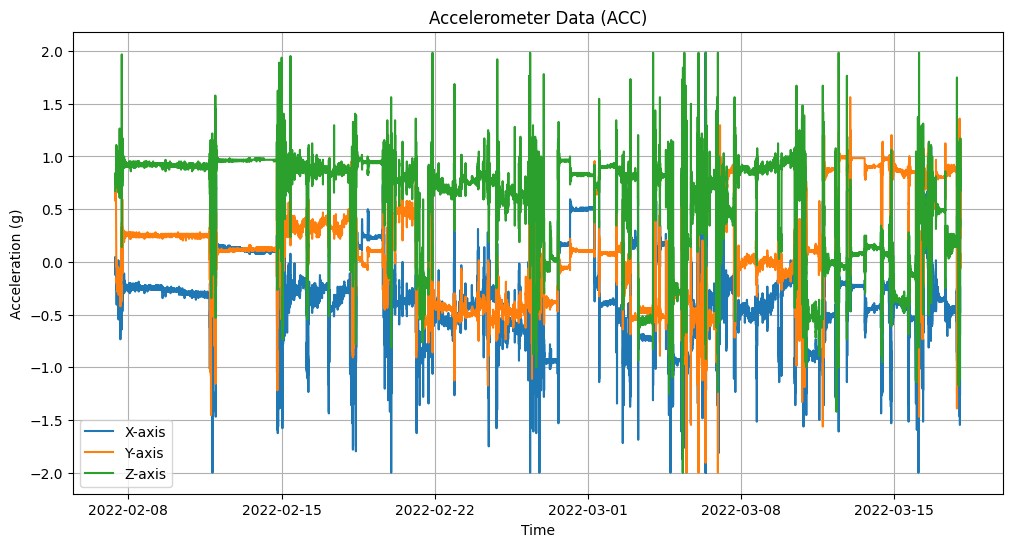

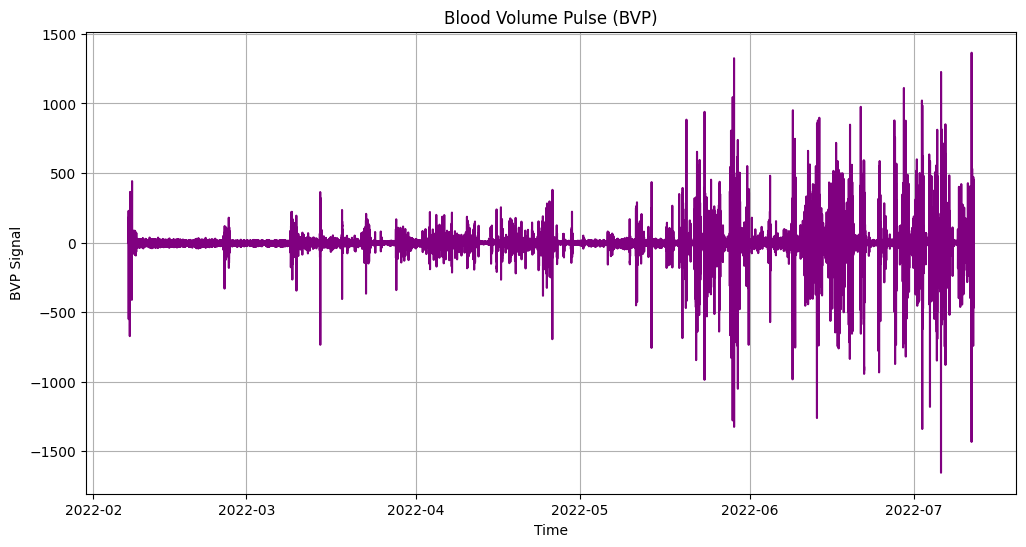

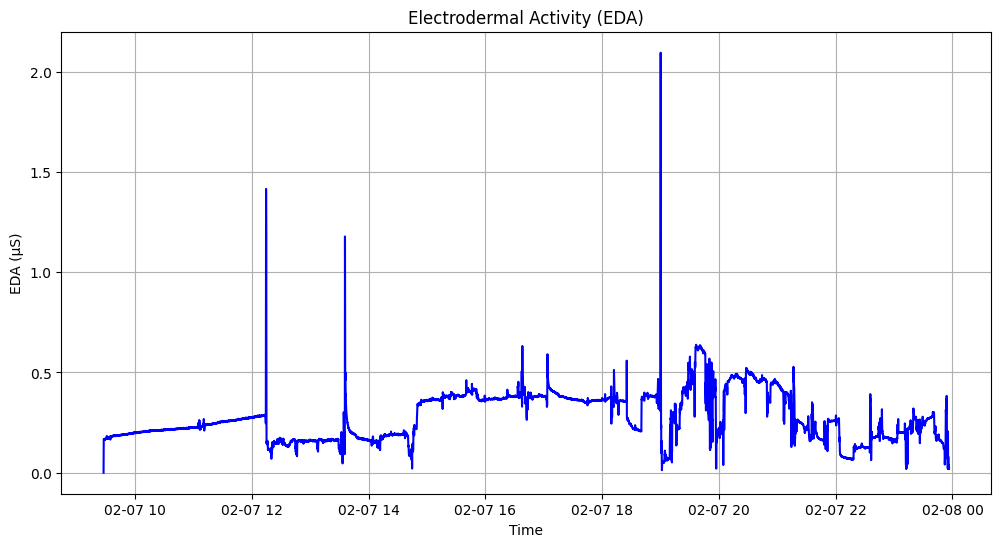

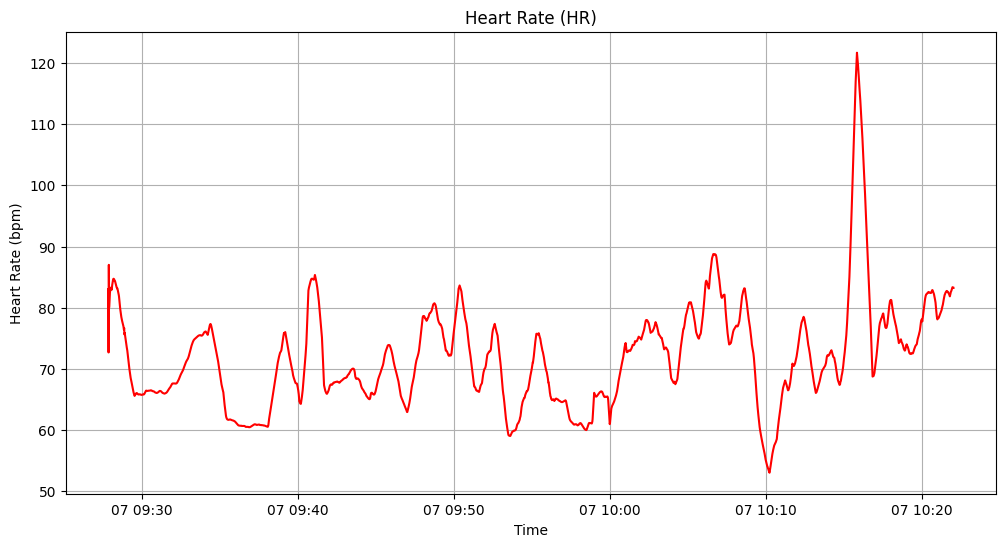

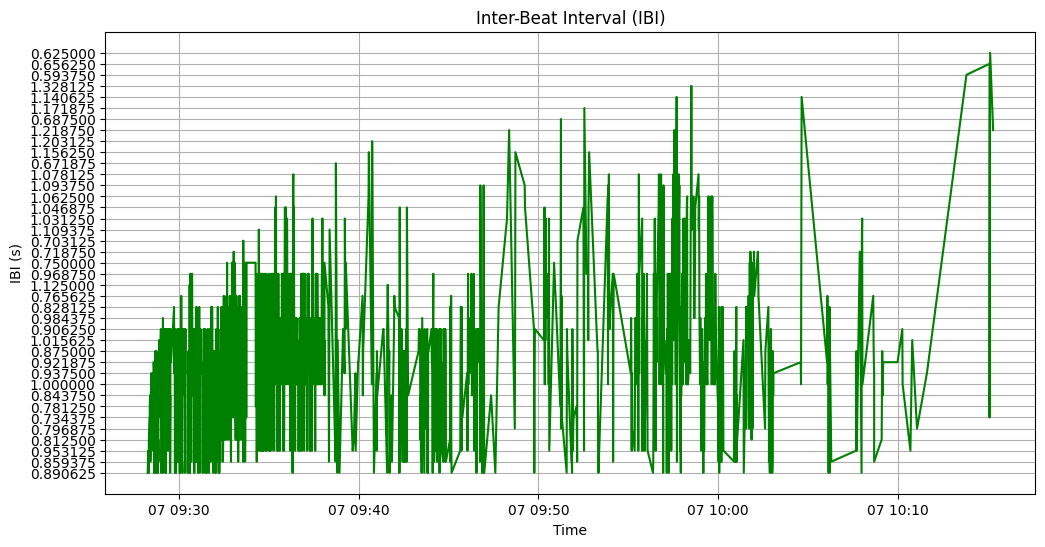

AttributeError: Line2D.set() got an unexpected keyword argument 'fontsize'

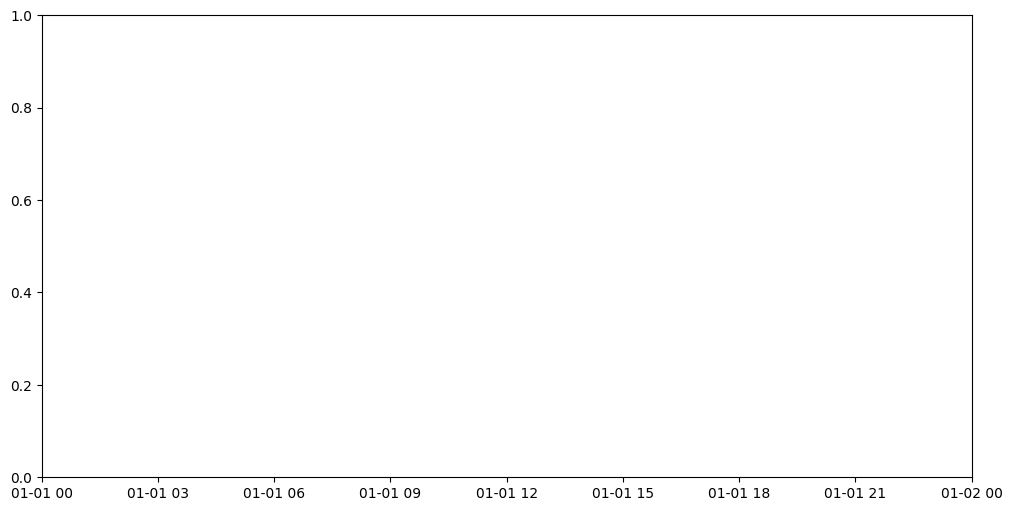

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_acc_data(acc_data):
    plt.figure(figsize=(12, 6))
    # The error was due to seaborn expecting a wide format dataframe
    # To fix this, we explicitly specify the x and y values for the lineplot
    # We use the index of the acc_data dataframe as the x-axis and the acceleration values as the y-axis
    sns.lineplot(x=acc_data.index, y=acc_data['acc_x'].squeeze(), label='X-axis')
    sns.lineplot(x=acc_data.index, y=acc_data['acc_y'].squeeze(), label='Y-axis')
    sns.lineplot(x=acc_data.index, y=acc_data['acc_z'].squeeze(), label='Z-axis')
    plt.title('Accelerometer Data (ACC)')
    plt.xlabel('Time')
    plt.ylabel('Acceleration (g)')
    # plt.legend(['X-axis', 'Y-axis', 'Z-axis']) # Legend is automatically generated now
    plt.grid(True)
    plt.show()

def plot_bvp_data(bvp_data):
    plt.figure(figsize=(12, 6))
    plt.plot(bvp_data.index, bvp_data['bvp'], color='purple')
    plt.title('Blood Volume Pulse (BVP)')
    plt.xlabel('Time')
    plt.ylabel('BVP Signal')
    plt.grid(True)
    plt.show()

def plot_eda_data(eda_data):
    plt.figure(figsize=(12, 6))
    plt.plot(eda_data.index, eda_data['eda'], color='blue')
    plt.title('Electrodermal Activity (EDA)')
    plt.xlabel('Time')
    plt.ylabel('EDA (µS)')
    plt.grid(True)
    plt.show()

def plot_hr_data(hr_data):
    plt.figure(figsize=(12, 6))
    plt.plot(hr_data.index, hr_data['hr'], color='red')
    plt.title('Heart Rate (HR)')
    plt.xlabel('Time')
    plt.ylabel('Heart Rate (bpm)')
    plt.grid(True)
    plt.show()

def plot_ibi_data(ibi_data):
    plt.figure(figsize=(12, 6))
    plt.plot(ibi_data.index, ibi_data['ibi'], color='green')
    plt.title('Inter-Beat Interval (IBI)')
    plt.xlabel('Time')
    plt.ylabel('IBI (s)')
    plt.grid(True)
    plt.show()

def plot_temp_data(temp_data):
    plt.figure(figsize=(12, 6))
    plt.plot(temp_data.index, temp_data['temp'], color='orange',fontsize=12)
    plt.title('Skin Temperature')
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Temperature (°C)', fontsize=12)
    plt.grid(True)
    plt.show()

# Call plotting functions
plot_acc_data(acc_data)
plot_bvp_data(bvp_data)
plot_eda_data(eda_data)
plot_hr_data(hr_data)
plot_ibi_data(ibi_data)
plot_temp_data(temp_data)


In [ ]:
import pandas as pd

def merge_sensor_data(acc_data, bvp_data, eda_data, hr_data, ibi_data, temp_data):
    # Perform an outer join to ensure all data is retained, aligning on timestamps
    merged_data = acc_data.join([bvp_data, eda_data, hr_data, ibi_data, temp_data], how='outer')

    # Sort by index (timestamp) for chronological order
    merged_data = merged_data.sort_index()

    # Handle missing values using interpolation for smooth transitions
    merged_data = merged_data.interpolate(method='time').ffill().bfill()

    return merged_data

# Example Usage
merged_data = merge_sensor_data(acc_data, bvp_data, eda_data, hr_data, ibi_data, temp_data)
print(merged_data.head())


                     (acc_x,)  (acc_y,)  (acc_z,)  bvp       eda    hr  \
2022-02-07 09:27:41  -0.03125  0.671875  0.671875  0.0  0.000000  83.0   
2022-02-07 09:27:45  -0.03125  0.673828  0.677734  0.0  0.112750  83.0   
2022-02-07 09:27:49  -0.03125  0.675781  0.683594  0.0  0.166563  83.0   
2022-02-07 09:27:51  -0.03125  0.676758  0.686523  0.0  0.167204  83.0   
2022-02-07 09:27:52  -0.03125  0.677246  0.687988  0.0  0.167524  83.0   

                          ibi   temp  
2022-02-07 09:27:41  0.890625  28.39  
2022-02-07 09:27:45  0.890625  28.39  
2022-02-07 09:27:49  0.890625  28.39  
2022-02-07 09:27:51  0.890625  28.39  
2022-02-07 09:27:52  0.890625  28.39  


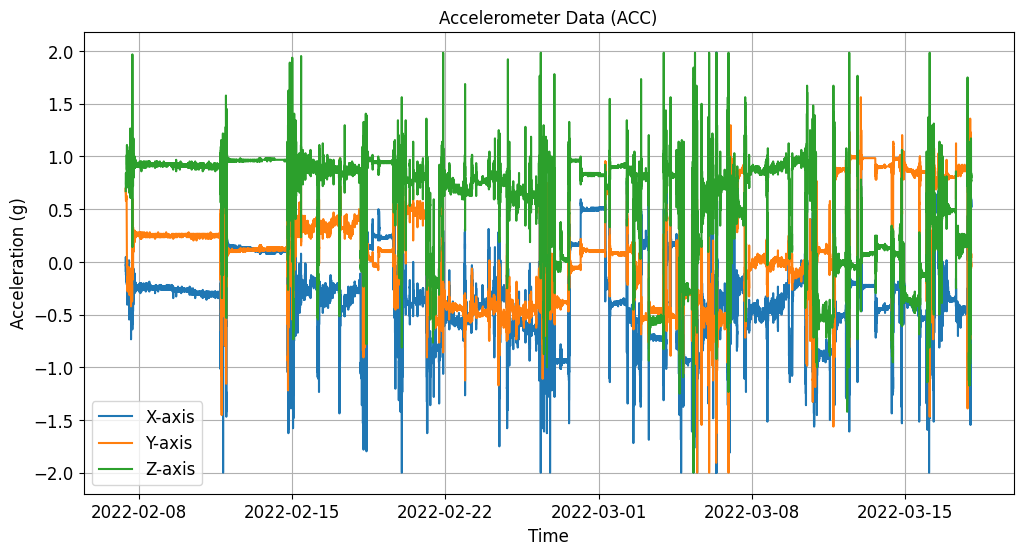

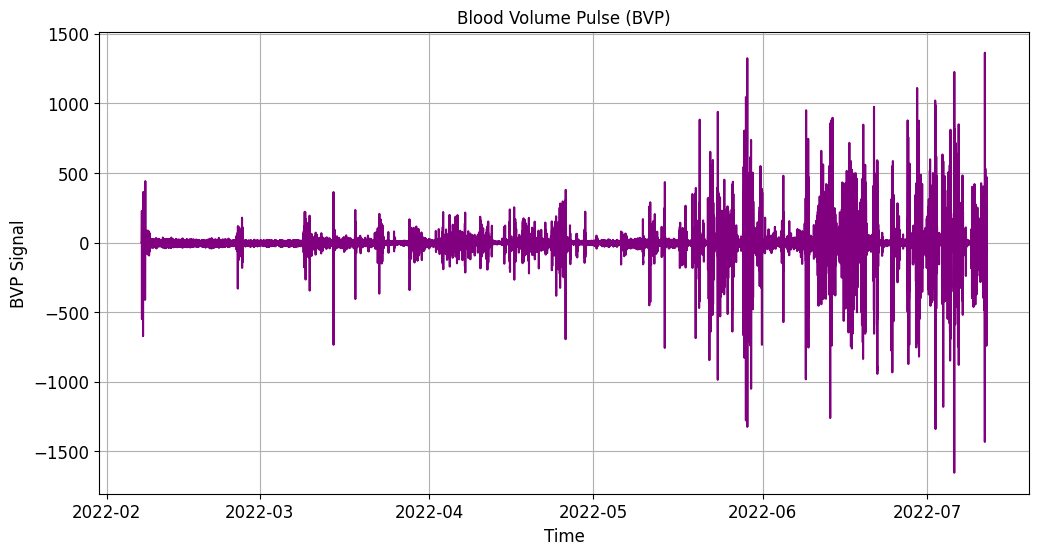

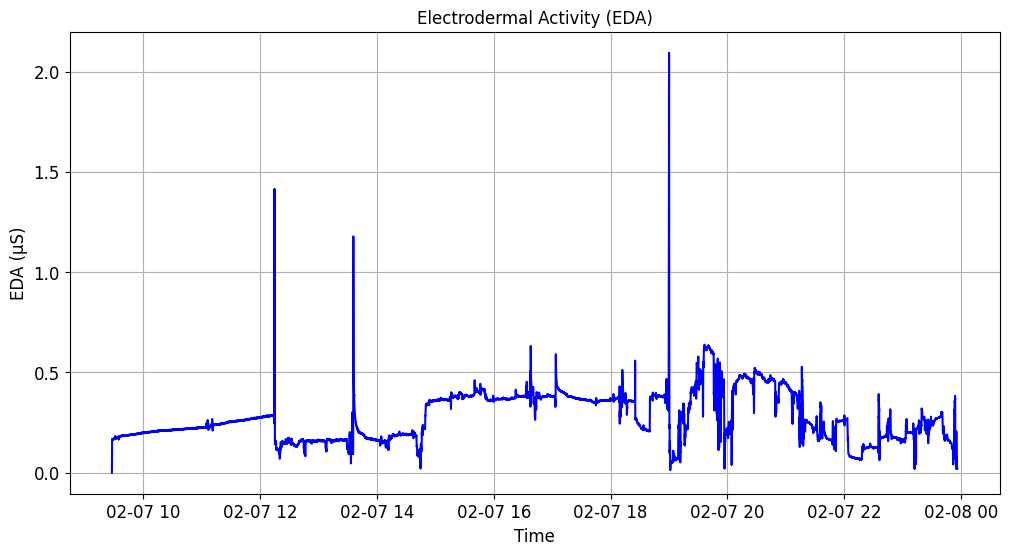

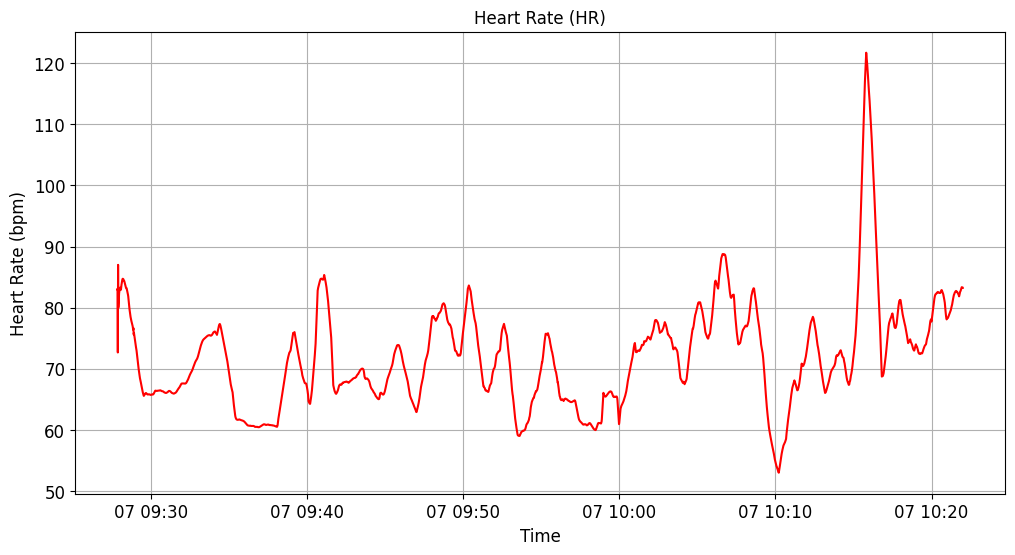

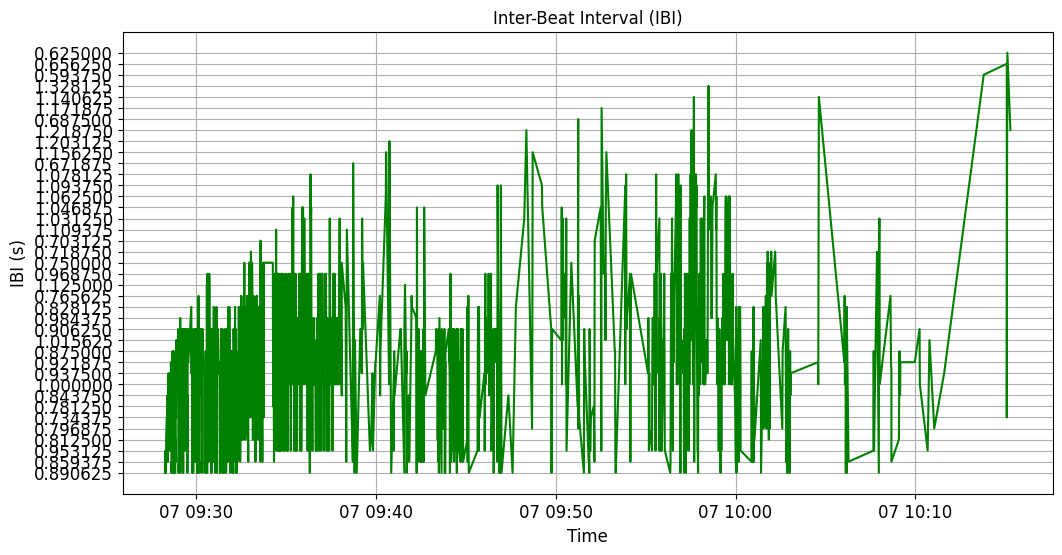

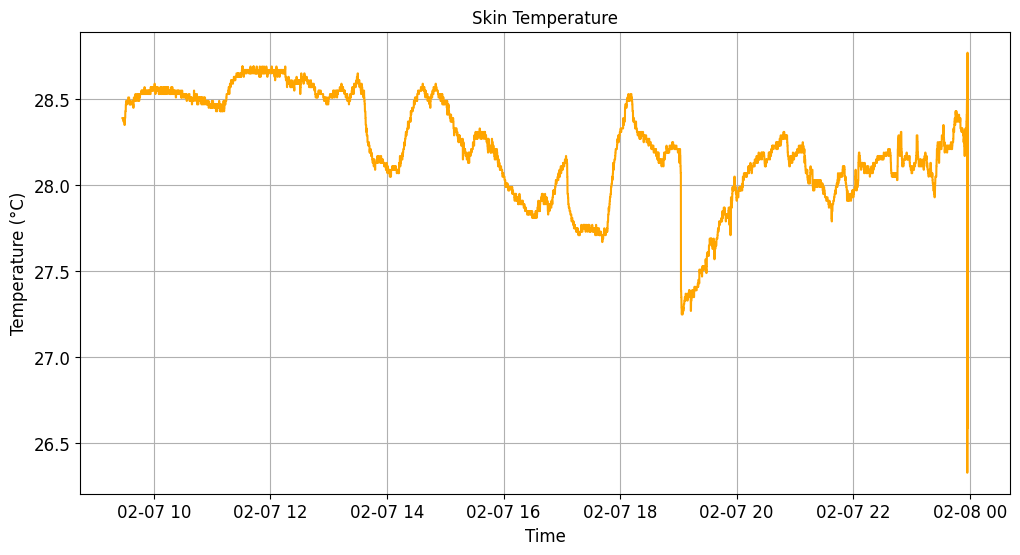

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_acc_data(acc_data):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=acc_data.index, y=acc_data['acc_x'].squeeze(), label='X-axis')
    sns.lineplot(x=acc_data.index, y=acc_data['acc_y'].squeeze(), label='Y-axis')
    sns.lineplot(x=acc_data.index, y=acc_data['acc_z'].squeeze(), label='Z-axis')
    plt.title('Accelerometer Data (ACC)', fontsize=12) # Set title fontsize
    plt.xlabel('Time', fontsize=12) # Set xlabel fontsize
    plt.ylabel('Acceleration (g)', fontsize=12) # Set ylabel fontsize
    plt.tick_params(axis='both', which='major', labelsize=12) # Set tick labels fontsize
    plt.legend(fontsize=12) # Set legend fontsize
    plt.grid(True)
    plt.show()

def plot_bvp_data(bvp_data):
    plt.figure(figsize=(12, 6))
    plt.plot(bvp_data.index, bvp_data['bvp'], color='purple')
    plt.title('Blood Volume Pulse (BVP)', fontsize=12) # Set title fontsize
    plt.xlabel('Time', fontsize=12) # Set xlabel fontsize
    plt.ylabel('BVP Signal', fontsize=12) # Set ylabel fontsize
    plt.tick_params(axis='both', which='major', labelsize=12) # Set tick labels fontsize
    plt.grid(True)
    plt.show()

def plot_eda_data(eda_data):
    plt.figure(figsize=(12, 6))
    plt.plot(eda_data.index, eda_data['eda'], color='blue')
    plt.title('Electrodermal Activity (EDA)', fontsize=12) # Set title fontsize
    plt.xlabel('Time', fontsize=12) # Set xlabel fontsize
    plt.ylabel('EDA (µS)', fontsize=12) # Set ylabel fontsize
    plt.tick_params(axis='both', which='major', labelsize=12) # Set tick labels fontsize
    plt.grid(True)
    plt.show()

def plot_hr_data(hr_data):
    plt.figure(figsize=(12, 6))
    plt.plot(hr_data.index, hr_data['hr'], color='red')
    plt.title('Heart Rate (HR)', fontsize=12) # Set title fontsize
    plt.xlabel('Time', fontsize=12) # Set xlabel fontsize
    plt.ylabel('Heart Rate (bpm)', fontsize=12) # Set ylabel fontsize
    plt.tick_params(axis='both', which='major', labelsize=12) # Set tick labels fontsize
    plt.grid(True)
    plt.show()

def plot_ibi_data(ibi_data):
    plt.figure(figsize=(12, 6))
    plt.plot(ibi_data.index, ibi_data['ibi'], color='green')
    plt.title('Inter-Beat Interval (IBI)', fontsize=12) # Set title fontsize
    plt.xlabel('Time', fontsize=12) # Set xlabel fontsize
    plt.ylabel('IBI (s)', fontsize=12) # Set ylabel fontsize
    plt.tick_params(axis='both', which='major', labelsize=12) # Set tick labels fontsize
    plt.grid(True)
    plt.show()

def plot_temp_data(temp_data):
    plt.figure(figsize=(12, 6))
    plt.plot(temp_data.index, temp_data['temp'], color='orange')
    plt.title('Skin Temperature', fontsize=12) # Set title fontsize
    plt.xlabel('Time', fontsize=12) # Set xlabel fontsize
    plt.ylabel('Temperature (°C)', fontsize=12) # Set ylabel fontsize
    plt.tick_params(axis='both', which='major', labelsize=12) # Set tick labels fontsize
    plt.grid(True)
    plt.show()

# Call plotting functions
plot_acc_data(acc_data)
plot_bvp_data(bvp_data)
plot_eda_data(eda_data)
plot_hr_data(hr_data)
plot_ibi_data(ibi_data)
plot_temp_data(temp_data)

In [ ]:
merged_data.shape

(274826, 8)

In [ ]:
import pandas as pd

def merge_sensor_data(acc_data, bvp_data, eda_data, hr_data, ibi_data, temp_data):
    # Perform an outer join to ensure all data is retained, aligning on timestamps
    merged_data = acc_data.join([bvp_data, eda_data, hr_data, ibi_data, temp_data], how='outer')

    # Sort by index (timestamp) for chronological order
    merged_data = merged_data.sort_index()

    # Handle missing values using interpolation for smooth transitions
    merged_data = merged_data.interpolate(method='time').ffill().bfill()

    return merged_data

# Example Usage
folder_path = "/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data/S02"

df1 = get_acc_data(folder_path)
df2 = get_bvp_data(folder_path)
df3 = get_eda_data(folder_path)
df4 = get_hr_data(folder_path)
df5 = get_ibi_data(folder_path)
df6 = get_temp_data(folder_path)
merged_data_s2 = merge_sensor_data(df1,df2,df3,df4,df5,df6)
print(merged_data_s2.head())


                               acc_x     acc_y     acc_z  bvp       eda  \
2022-02-07 09:52:54.000000  0.031250  0.156250  0.984375 -0.0  0.000000   
2022-02-07 09:52:54.031250  0.062500  0.187500  1.031250  0.0  0.004865   
2022-02-07 09:52:54.062500 -0.015625  0.203125  0.984375  0.0  0.009731   
2022-02-07 09:52:54.093750 -0.109375  0.171875  0.921875  0.0  0.014596   
2022-02-07 09:52:54.125000 -0.109375  0.093750  0.890625  0.0  0.019461   

                               hr       ibi   temp  
2022-02-07 09:52:54.000000  118.0  0.687500  34.79  
2022-02-07 09:52:54.031250  118.0  0.687500  34.79  
2022-02-07 09:52:54.062500  118.0  0.687500  34.79  
2022-02-07 09:52:54.093750  118.0  0.687500  34.79  
2022-02-07 09:52:54.125000  118.0  0.687500  34.79  


In [ ]:
import pandas as pd

def merge_sensor_data(acc_data, bvp_data, eda_data, hr_data, ibi_data, temp_data):
    # Ensure proper index name
    for df in [acc_data, bvp_data, eda_data, hr_data, ibi_data, temp_data]:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError("All dataframes must have a DatetimeIndex.")
        df.index.name = 'timestamp'

    # Perform outer join for all except IBI (since IBI has sparse data)
    merged_data = acc_data.join([bvp_data, eda_data, hr_data, temp_data], how='outer')

    # Merge IBI using merge_asof for nearest timestamp match
    merged_data = pd.merge_asof(
        merged_data.reset_index(),
        ibi_data.reset_index(),
        on='timestamp',
        direction='nearest'
    ).set_index('timestamp')

    # Sort and interpolate
    merged_data = merged_data.sort_index().interpolate(method='time').ffill().bfill()

    return merged_data

# Example Usage
folder_path = "/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data/S34"
df1 = get_acc_data(folder_path)
df2 = get_bvp_data(folder_path)
df3 = get_eda_data(folder_path)
df4 = get_hr_data(folder_path)
df5 = get_ibi_data(folder_path)
df6 = get_temp_data(folder_path)

merged_data_s34 = merge_sensor_data(df1, df2, df3, df4, df5, df6)
print(merged_data_s34.head())


                               acc_x     acc_y     acc_z  bvp       eda    hr  \
timestamp                                                                       
2022-03-09 14:36:34.000000 -0.046875 -0.078125  0.984375 -0.0  0.000000  78.0   
2022-03-09 14:36:34.031250 -0.046875 -0.078125  0.984375  0.0  0.000841  78.0   
2022-03-09 14:36:34.062500 -0.046875 -0.078125  1.000000  0.0  0.001682  78.0   
2022-03-09 14:36:34.093750 -0.046875 -0.078125  0.984375  0.0  0.002523  78.0   
2022-03-09 14:36:34.125000 -0.062500 -0.078125  0.984375  0.0  0.003363  78.0   

                             temp       ibi  
timestamp                                    
2022-03-09 14:36:34.000000  33.59  0.703125  
2022-03-09 14:36:34.031250  33.59  0.703125  
2022-03-09 14:36:34.062500  33.59  0.703125  
2022-03-09 14:36:34.093750  33.59  0.703125  
2022-03-09 14:36:34.125000  33.59  0.703125  


#### Testing for Single Raw Data

In [ ]:
folder_path = "/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data/S02"

df1 = get_acc_data(folder_path)
df2 = get_bvp_data(folder_path)
df3 = get_eda_data(folder_path)
df4 = get_hr_data(folder_path)
df5 = get_ibi_data(folder_path)
df6 = get_temp_data(folder_path)

# merged = pd.merge_asof(df1, df2)
merged = pd.merge(df1, df2, left_index=True, right_index=True, how='outer')
print(merged.size)
merged = pd.merge(merged, df3, left_index=True, right_index=True, how='outer')
print(merged.size)
merged = pd.merge(merged, df4, left_index=True, right_index=True, how='outer')
print(merged.size)
merged = pd.merge(merged, df5, left_index=True, right_index=True, how='outer')
print(merged.size)
merged = pd.merge(merged, df6, left_index=True, right_index=True, how='outer')
print(merged.size)
merged

1368684
1773525
2128230
2483222
2837984


,acc_x,acc_y,acc_z,bvp,eda,hr,ibi,temp
2022-02-07 09:52:54.000000,0.031250,0.156250,0.984375,-0.00,0.0,NaN,NaN,34.79
2022-02-07 09:52:54.031250,0.062500,0.187500,1.031250,NaN,NaN,NaN,NaN,NaN
2022-02-07 09:52:54.062500,-0.015625,0.203125,0.984375,NaN,NaN,NaN,NaN,NaN
2022-02-07 09:52:54.093750,-0.109375,0.171875,0.921875,NaN,NaN,NaN,NaN,NaN
2022-02-07 09:52:54.125000,-0.109375,0.093750,0.890625,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2022-07-26 10:12:06.000000,NaN,NaN,NaN,0.11,NaN,NaN,NaN,NaN
2022-07-26 10:13:10.000000,NaN,NaN,NaN,1.57,NaN,NaN,NaN,NaN
2022-07-26 10:14:14.000000,NaN,NaN,NaN,-0.57,NaN,NaN,NaN,NaN
2022-07-26 10:15:18.000000,NaN,NaN,NaN,-5.74,NaN,NaN,NaN,NaN


#### Merging all Participants RAW data

In [ ]:


path = "/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data"
dfs = []
merge_how = "outer"
for folder in os.listdir(path):
    if folder.startswith('S'):
        folder_path = os.path.join(path, folder)
        participant = int(folder[1:])
        df1 = get_acc_data(folder_path)
        df2 = get_bvp_data(folder_path)
        df3 = get_eda_data(folder_path)
        df4 = get_hr_data(folder_path)
        df5 = get_ibi_data(folder_path)
        df6 = get_temp_data(folder_path)

        merged = pd.merge(df1, df2, left_index=True, right_index=True, how=merge_how)
        merged = pd.merge(merged, df3, left_index=True, right_index=True, how=merge_how)
        merged = pd.merge(merged, df4, left_index=True, right_index=True, how=merge_how)
        merged = pd.merge(merged, df5, left_index=True, right_index=True, how=merge_how)
        merged = pd.merge(merged, df6, left_index=True, right_index=True, how=merge_how)

        merged['participant'] = participant
        dfs.append(merged)

all_raw_data = pd.concat(dfs)
all_raw_data.columns = ['acc_x', 'acc_y', 'acc_z'] + list(all_raw_data.columns[3:])
all_raw_data

,acc_x,acc_y,acc_z,bvp,eda,hr,ibi,temp,participant
2022-03-09 14:36:34.000000,-0.046875,-0.078125,0.984375,-0.00,0.0,NaN,NaN,33.59,34
2022-03-09 14:36:34.031250,-0.046875,-0.078125,0.984375,NaN,NaN,NaN,NaN,NaN,34
2022-03-09 14:36:34.062500,-0.046875,-0.078125,1.000000,NaN,NaN,NaN,NaN,NaN,34
2022-03-09 14:36:34.093750,-0.046875,-0.078125,0.984375,NaN,NaN,NaN,NaN,NaN,34
2022-03-09 14:36:34.125000,-0.062500,-0.078125,0.984375,NaN,NaN,NaN,NaN,NaN,34
...,...,...,...,...,...,...,...,...,...
2022-07-13 14:00:08.000000,NaN,NaN,NaN,20.10,NaN,NaN,NaN,NaN,8
2022-07-13 14:01:12.000000,NaN,NaN,NaN,20.90,NaN,NaN,NaN,NaN,8
2022-07-13 14:02:16.000000,NaN,NaN,NaN,18.67,NaN,NaN,NaN,NaN,8
2022-07-13 14:03:20.000000,NaN,NaN,NaN,14.55,NaN,NaN,NaN,NaN,8


In [ ]:
import os
import pandas as pd

def merge_all_subject_data(path):
    dfs = []
    merge_how = "outer"

    for folder in os.listdir(path):
        if folder.startswith('S') and os.path.isdir(os.path.join(path, folder)):
            folder_path = os.path.join(path, folder)
            participant = int(folder[1:])

            # Extract sensor data
            df1 = get_acc_data(folder_path)
            df2 = get_bvp_data(folder_path)
            df3 = get_eda_data(folder_path)
            df4 = get_hr_data(folder_path)
            df5 = get_ibi_data(folder_path)
            df6 = get_temp_data(folder_path)

            # Merge all data using outer join
            merged = df1.join([df2, df3, df4, df5, df6], how=merge_how)

            # Add participant identifier
            merged['participant'] = participant
            dfs.append(merged)

    # Combine all participant data
    all_raw_data = pd.concat(dfs, axis=0)

    # Rename columns for clarity
    column_names = ['acc_x', 'acc_y', 'acc_z'] + list(all_raw_data.columns[3:])
    all_raw_data.columns = column_names

    return all_raw_data

# Example usage
path = "/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data"
all_raw_data = merge_all_subject_data(path)
print(all_raw_data.head())


                               acc_x     acc_y     acc_z  bvp  eda  hr  ibi  \
2022-03-09 14:36:34.000000 -0.046875 -0.078125  0.984375 -0.0  0.0 NaN  NaN   
2022-03-09 14:36:34.031250 -0.046875 -0.078125  0.984375  NaN  NaN NaN  NaN   
2022-03-09 14:36:34.062500 -0.046875 -0.078125  1.000000  NaN  NaN NaN  NaN   
2022-03-09 14:36:34.093750 -0.046875 -0.078125  0.984375  NaN  NaN NaN  NaN   
2022-03-09 14:36:34.125000 -0.062500 -0.078125  0.984375  NaN  NaN NaN  NaN   

                             temp  participant  
2022-03-09 14:36:34.000000  33.59           34  
2022-03-09 14:36:34.031250    NaN           34  
2022-03-09 14:36:34.062500    NaN           34  
2022-03-09 14:36:34.093750    NaN           34  
2022-03-09 14:36:34.125000    NaN           34  


In [ ]:
import os
import pandas as pd

def merge_sensor_data(acc_data, bvp_data, eda_data, hr_data, ibi_data, temp_data):
    # Ensure proper index name
    for df in [acc_data, bvp_data, eda_data, hr_data, ibi_data, temp_data]:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError("All dataframes must have a DatetimeIndex.")
        df.index.name = 'timestamp'

    # Perform outer join for all except IBI (since IBI has sparse data)
    merged_data = acc_data.join([bvp_data, eda_data, hr_data, temp_data], how='outer')

    # Merge IBI using merge_asof for nearest timestamp match
    merged_data = pd.merge_asof(
        merged_data.reset_index(),
        ibi_data.reset_index(),
        on='timestamp',
        direction='nearest'
    ).set_index('timestamp')

    # Sort and interpolate
    merged_data = merged_data.sort_index().interpolate(method='time').ffill().bfill()

    return merged_data

def merge_all_participants(base_path):
    dfs = []
    for folder in os.listdir(base_path):
        if folder.startswith('S'):
            folder_path = os.path.join(base_path, folder)
            participant = int(folder[1:])

            df1 = get_acc_data(folder_path)
            df2 = get_bvp_data(folder_path)
            df3 = get_eda_data(folder_path)
            df4 = get_hr_data(folder_path)
            df5 = get_ibi_data(folder_path)
            df6 = get_temp_data(folder_path)

            merged_data = merge_sensor_data(df1, df2, df3, df4, df5, df6)
            merged_data['participant'] = participant
            dfs.append(merged_data)

    # Combine all participant data
    all_data = pd.concat(dfs)
    all_data.columns = ['acc_x', 'acc_y', 'acc_z'] + list(all_data.columns[3:])

    return all_data

# Example Usage
path = "/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data"
all_data = merge_all_participants(path)
print(all_data.head())


                               acc_x     acc_y     acc_z  bvp       eda    hr  \
timestamp                                                                       
2022-03-09 14:36:34.000000 -0.046875 -0.078125  0.984375 -0.0  0.000000  78.0   
2022-03-09 14:36:34.031250 -0.046875 -0.078125  0.984375  0.0  0.000841  78.0   
2022-03-09 14:36:34.062500 -0.046875 -0.078125  1.000000  0.0  0.001682  78.0   
2022-03-09 14:36:34.093750 -0.046875 -0.078125  0.984375  0.0  0.002523  78.0   
2022-03-09 14:36:34.125000 -0.062500 -0.078125  0.984375  0.0  0.003363  78.0   

                             temp       ibi  participant  
timestamp                                                 
2022-03-09 14:36:34.000000  33.59  0.703125           34  
2022-03-09 14:36:34.031250  33.59  0.703125           34  
2022-03-09 14:36:34.062500  33.59  0.703125           34  
2022-03-09 14:36:34.093750  33.59  0.703125           34  
2022-03-09 14:36:34.125000  33.59  0.703125           34  


In [ ]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11548434 entries, 2022-03-09 14:36:34 to 2022-07-13 14:04:24
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   acc_x        float64
 1   acc_y        float64
 2   acc_z        float64
 3   bvp          float64
 4   eda          float64
 5   hr           float64
 6   temp         float64
 7   ibi          object 
 8   participant  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 881.1+ MB


#### Getting Ground Truth Label from the Processed Data

In [ ]:
label_data = pd.read_csv(r'/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Processed_data/Improved_All_Combined_hr_rsp_binary.csv')

print(label_data.columns)
# set ""Time(sec)"" column as index and convert to datetime index
label_data = label_data.set_index(pd.to_datetime(label_data["Time(sec)"], unit='s'))

# drop the original "Time" column
label_data = label_data.drop("Time(sec)", axis=1)

# we are dropping HR and resp data. We took it from raw data
label_data.drop(['HR', 'respr'], axis=1, inplace=True)
label_data

Index(['Participant', 'HR', 'respr', 'Time(sec)', 'Label'], dtype='object')


,Participant,Label
Time(sec),,
2022-02-07 09:53:03,2,0
2022-02-07 09:53:04,2,0
2022-02-07 09:53:05,2,0
2022-02-07 09:53:06,2,0
2022-02-07 09:53:07,2,0
...,...,...
2022-03-09 16:10:43,35,0
2022-03-09 16:10:44,35,0
2022-03-09 16:10:45,35,0


In [ ]:
import pandas as pd

# Load label data
label_data = pd.read_csv('/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Processed_data/Improved_All_Combined_hr_rsp_binary.csv')

# Print column names for verification
print("Columns in CSV:", label_data.columns)

# Convert "Time(sec)" to datetime and store in a new column called "timestamp"
if 'Time(sec)' in label_data.columns:
    label_data['timestamp'] = pd.to_datetime(label_data['Time(sec)'], unit='s')
else:
    print("Error: 'Time(sec)' column not found.")

# Drop HR and respr data if present
label_data.drop(['HR', 'respr','Time(sec)'], axis=1, errors='ignore', inplace=True)

# Display the final dataframe
print(label_data.head())


Columns in CSV: Index(['Participant', 'HR', 'respr', 'Time(sec)', 'Label'], dtype='object')
   Participant  Label           timestamp
0            2      0 2022-02-07 09:53:03
1            2      0 2022-02-07 09:53:04
2            2      0 2022-02-07 09:53:05
3            2      0 2022-02-07 09:53:06
4            2      0 2022-02-07 09:53:07


#### Combining RAW Data and Ground Truth Label Information

In [ ]:

all_combined_data = pd.DataFrame()
# We dont have participant 1 ground truth data
for i in range(2,36,1):
    this_participant_label_data = label_data[label_data['Participant'] == i]
    this_participant_rawdata = all_raw_data[all_raw_data['participant'] == i]
    this_participant_merged = pd.merge(this_participant_rawdata, this_participant_label_data, left_index=True, right_index=True, how='inner')

    all_combined_data = pd.concat([all_combined_data, this_participant_merged])

all_combined_data

,acc_x,acc_y,acc_z,bvp,eda,hr,ibi,temp,participant,Participant,Label
2022-02-07 09:53:03,-0.453125,0.062500,0.890625,NaN,NaN,NaN,NaN,NaN,2,2,0
2022-02-07 09:53:04,-0.437500,0.093750,0.890625,NaN,NaN,118.00,NaN,NaN,2,2,0
2022-02-07 09:53:05,-0.312500,0.046875,0.953125,NaN,NaN,113.50,NaN,NaN,2,2,0
2022-02-07 09:53:06,-0.656250,-0.406250,0.812500,NaN,0.883157,93.00,NaN,34.79,2,2,0
2022-02-07 09:53:07,-0.968750,-0.187500,-0.156250,NaN,NaN,93.25,NaN,NaN,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...
2022-03-09 16:10:42,-0.265625,-0.109375,0.968750,NaN,NaN,65.37,NaN,NaN,35,35,0
2022-03-09 16:10:43,-0.296875,-0.078125,0.937500,NaN,NaN,65.42,NaN,NaN,35,35,0
2022-03-09 16:10:44,-0.281250,-0.015625,0.968750,42.54,0.480766,65.45,NaN,33.53,35,35,0
2022-03-09 16:10:45,-0.250000,0.000000,0.968750,NaN,NaN,65.47,NaN,NaN,35,35,0


In [ ]:
all_data.columns

Index(['acc_x', 'acc_y', 'acc_z', 'bvp', 'eda', 'hr', 'temp', 'ibi',
       'participant'],
      dtype='object')

In [ ]:
label_data.columns

Index(['Participant', 'Label'], dtype='object')

In [ ]:
import pandas as pd

combined_data_list = []

# We don't have ground truth data for participant 1
for i in range(2, 36):
    # Extract participant-specific data
    this_participant_label_data = label_data[label_data['Participant'] == i]
    this_participant_rawdata = all_data[all_data['participant'] == i]

    if not this_participant_label_data.empty and not this_participant_rawdata.empty:
        # Prepare raw data: Reset index to bring timestamp into a column
        this_participant_rawdata = this_participant_rawdata.reset_index().rename(columns={'index': 'timestamp'})
        this_participant_rawdata['participant'] = i  # ensure participant column is present

        # Prepare label data: rename 'Time(sec)' to 'timestamp'
        this_participant_label_data = this_participant_label_data.rename(columns={'Time(sec)': 'timestamp'})
        this_participant_label_data['participant'] = i  # ensure participant column is present

        # Merge on both timestamp and participant
        this_participant_merged = pd.merge(
            this_participant_rawdata,
            this_participant_label_data,
            on=['timestamp', 'participant'],
            how='inner'
        )
        combined_data_list.append(this_participant_merged)
        print(f"Participant {i}: Merged {len(this_participant_merged)} rows.")
    else:
        print(f"Participant {i}: No matching data found.")

# Concatenate all merged data
all_combined_data = pd.concat(combined_data_list, ignore_index=True)

print("Final Combined Data Shape:", all_combined_data.shape)


Participant 2: Merged 3556 rows.
Participant 3: Merged 3309 rows.
Participant 4: Merged 3530 rows.
Participant 5: Merged 3269 rows.
Participant 6: Merged 3310 rows.
Participant 7: Merged 3371 rows.
Participant 8: Merged 3135 rows.
Participant 9: Merged 3177 rows.
Participant 10: Merged 3029 rows.
Participant 11: Merged 3270 rows.
Participant 12: Merged 3333 rows.
Participant 13: Merged 3337 rows.
Participant 14: Merged 3567 rows.
Participant 15: Merged 3450 rows.
Participant 16: Merged 3437 rows.
Participant 17: Merged 3303 rows.
Participant 18: Merged 3413 rows.
Participant 19: Merged 3185 rows.
Participant 20: Merged 3388 rows.
Participant 21: Merged 3218 rows.
Participant 22: Merged 3055 rows.
Participant 23: Merged 3080 rows.
Participant 24: Merged 3269 rows.
Participant 25: Merged 3204 rows.
Participant 26: Merged 3231 rows.
Participant 27: Merged 3370 rows.
Participant 28: Merged 3298 rows.
Participant 29: Merged 3286 rows.
Participant 30: Merged 3328 rows.
Participant 31: Merged

##### Combined DF with all the processed RAW data and Ground truth information from each participants.

In [ ]:
all_combined_data = all_combined_data.reset_index()


In [ ]:
filtered_data = all_combined_data[all_combined_data['Label'] == 1]
print(filtered_data)

In [ ]:
all_combined_data

### Feature Extraction & Analysis

#### Feature Analysis

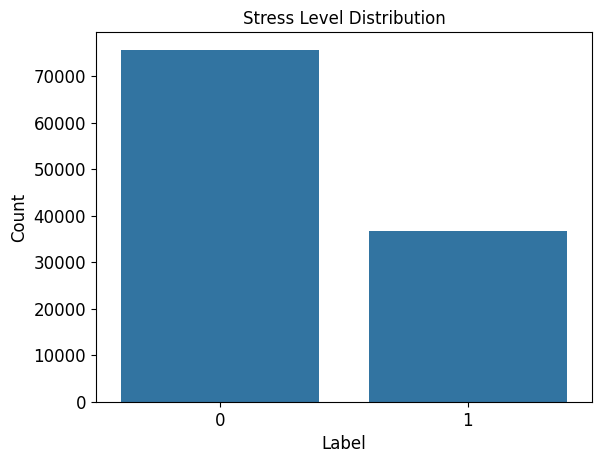

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# You can control font sizes globally or on specific axes after plotting
# For example, to set the overall figure title and axis labels font size:
# plt.rcParams.update({'font.size': 12})

sns.countplot(x = all_combined_data['Label'])
plt.title('Stress Level Distribution', fontsize=12) # Set title fontsize
plt.xlabel('Label', fontsize=12) # Set xlabel fontsize
plt.ylabel('Count', fontsize=12) # Set ylabel fontsize
plt.tick_params(axis='both', which='major', labelsize=12) # Set tick labels fontsize

plt.show()

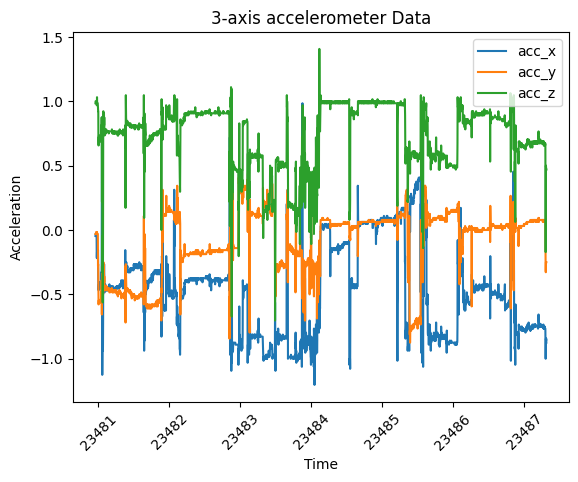

In [ ]:
participant = 9
p = all_combined_data[all_combined_data['participant'] == participant]
p = p.dropna()

fig, ax = plt.subplots()
ax.plot(p.index, p['acc_x'], label='acc_x')
ax.plot(p.index, p['acc_y'], label='acc_y')
ax.plot(p.index, p['acc_z'], label='acc_z')
plt.xlabel('Time')
plt.ylabel('Acceleration')
plt.legend()

ax.set_xticklabels(p.index, rotation=45)
plt.title("3-axis accelerometer Data")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

participant = 9
p = all_combined_data[all_combined_data['participant'] == participant].dropna()

# Plot Configuration
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(p.index, p['acc_x'], label='acc_x', alpha=0.8)
ax.plot(p.index, p['acc_y'], label='acc_y', alpha=0.8)
ax.plot(p.index, p['acc_z'], label='acc_z', alpha=0.8)

# Axis Labels and Title
plt.xlabel('Time')
plt.ylabel('Acceleration')
plt.title(f"3-axis Accelerometer Data for Participant {participant}")

# Formatting X-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# Additional Features
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Show Plot
plt.show()


In [ ]:
# Change me to get different participant data
participant = 9
parti2 = 10
p = all_combined_data[all_combined_data['participant'] == participant]
p = p.dropna()

p2 = all_combined_data[all_combined_data['participant'] == parti2]
p2 = p2.dropna()

# Create subplots
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(16, 16))

# Plot HR
ax1.plot(p.index, p['hr'],label=f'Average Heart Rate for S{participant}')
ax1.plot(p2.index, p2['hr'],label=f'Average Heart Rate for S{parti2}')
ax1.set_title('Heart Rate')
ax1.legend()

# Plot IBI
ax2.plot(p.index, p['bvp'], label=f'Data from photoplethysmograph for S{participant}')
ax2.plot(p2.index, p2['bvp'], label=f'Data from photoplethysmograph for S{parti2}')
ax2.set_title('BVP')
ax2.legend()

ax3.plot(p.index, p['temp'], label=f'Temp in (°C) for S{participant}')
ax3.plot(p2.index, p2['temp'], label=f'Temp in (°C) for S{parti2}')
ax3.set_title('Temparature data')
ax3.legend()

ax4.plot(p.index, p['eda'], label=f'Electrodermal activity sensor for S{participant}')
ax4.plot(p2.index, p2['eda'], label=f'Electrodermal activity sensor for S{parti2}')
ax4.set_title('EDA data')
ax4.legend()

ax5.plot(p.index, p['ibi'], label=f'Inter-beat interval for S{participant}')
ax5.plot(p2.index, p2['ibi'], label=f'Inter-beat interval for S{parti2}')
ax5.set_title('Inter-beat interval')
ax5.set_xticklabels(p.index, rotation=20)
ax5.legend()

# Show the plots
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Change to get different participant data
participant = 9
parti2 = 10
p = all_combined_data[all_combined_data['participant'] == participant].dropna()
p2 = all_combined_data[all_combined_data['participant'] == parti2].dropna()

# Create subplots
fig, axs = plt.subplots(5, 1, figsize=(16, 20), sharex=True)

# Plot HR
axs[0].plot(p.index, p['hr'], label=f'Average Heart Rate for S{participant}')
axs[0].plot(p2.index, p2['hr'], label=f'Average Heart Rate for S{parti2}')
axs[0].set_title('Heart Rate')
axs[0].legend()
axs[0].grid(True)

# Plot BVP
axs[1].plot(p.index, p['bvp'], label=f'Data from photoplethysmograph for S{participant}')
axs[1].plot(p2.index, p2['bvp'], label=f'Data from photoplethysmograph for S{parti2}')
axs[1].set_title('BVP Data')
axs[1].legend()
axs[1].grid(True)

# Plot Temperature
axs[2].plot(p.index, p['temp'], label=f'Temperature (°C) for S{participant}')
axs[2].plot(p2.index, p2['temp'], label=f'Temperature (°C) for S{parti2}')
axs[2].set_title('Temperature Data')
axs[2].legend()
axs[2].grid(True)

# Plot EDA
axs[3].plot(p.index, p['eda'], label=f'EDA for S{participant}')
axs[3].plot(p2.index, p2['eda'], label=f'EDA for S{parti2}')
axs[3].set_title('Electrodermal Activity Data')
axs[3].legend()
axs[3].grid(True)

# Plot IBI
axs[4].plot(p.index, p['ibi'], label=f'Inter-beat Interval for S{participant}')
axs[4].plot(p2.index, p2['ibi'], label=f'Inter-beat Interval for S{parti2}')
axs[4].set_title('Inter-beat Interval')
axs[4].legend()
axs[4].grid(True)

# Format x-axis with time
axs[4].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
axs[4].xaxis.set_major_locator(mdates.AutoDateLocator())

# Improve Layout
plt.tight_layout()
plt.show()


### Feature Selection

Basic Statistics:
                           timestamp          acc_x          acc_y  \
count                         112508  112508.000000  112508.000000   
mean   2022-02-24 08:45:52.377271040      -0.539141      -0.023905   
min              2022-02-07 09:53:03      -2.000000      -1.656250   
25%    2022-02-14 13:38:57.750000128      -0.812500      -0.187500   
50%       2022-02-21 16:22:44.500000      -0.546875      -0.031250   
75%    2022-03-07 10:18:28.249999872      -0.328125       0.125000   
max              2022-03-09 16:10:46       1.328125       1.984375   
std                              NaN       0.338430       0.321364   

               acc_z            bvp            eda             hr  \
count  112508.000000  112508.000000  112508.000000  112508.000000   
mean        0.586131       6.641167       0.452099      80.215020   
min        -2.000000      -0.050000       0.015643      49.000000   
25%         0.359375       0.000000       0.153110      71.330000   
50%   

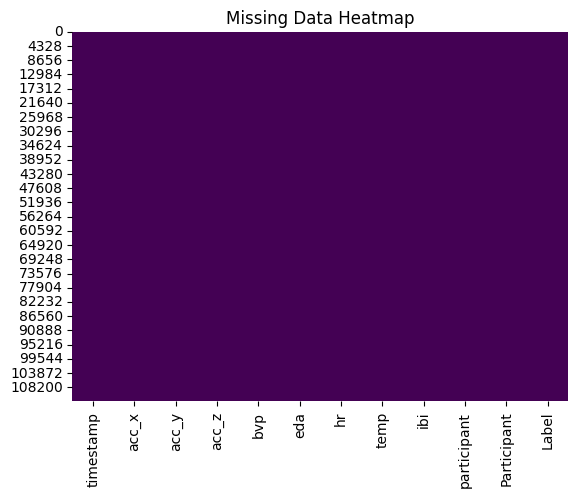

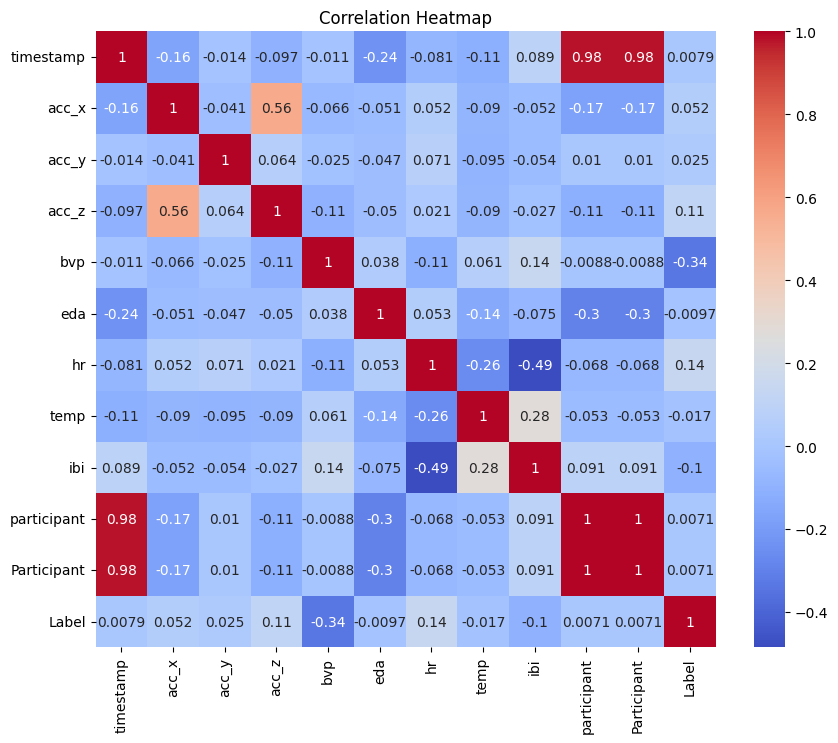

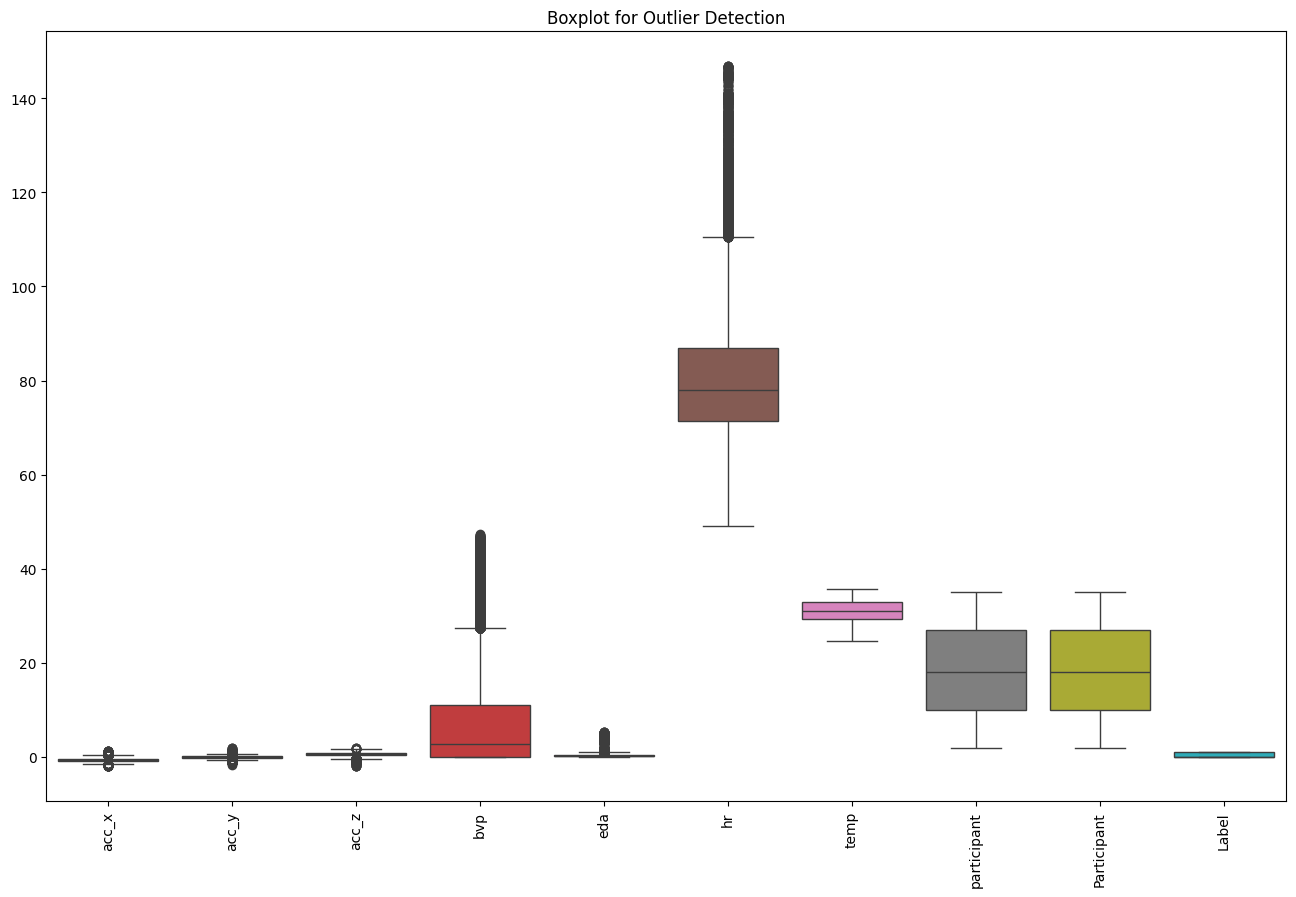

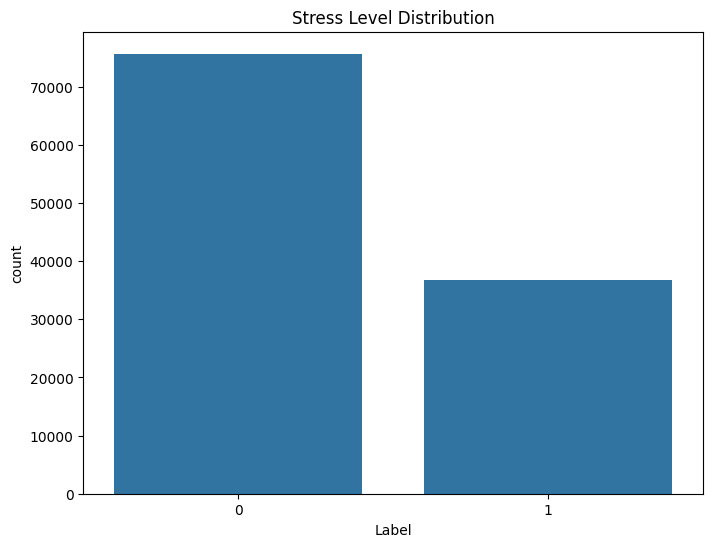

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Basic Statistical Analysis
def basic_stats(data):
    print("Basic Statistics:")
    print(data.describe())

# Missing Value Analysis
def missing_values(data):
    print("\nMissing Values:")
    print(data.isnull().sum())
    sns.heatmap(data.isnull(), cmap='viridis', cbar=False)
    plt.title('Missing Data Heatmap')
    plt.show()

# Correlation Heatmap
def plot_correlation(data):
    plt.figure(figsize=(10,8))
    sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()

# Boxplots for Outlier Detection
def plot_boxplots(data):
    plt.figure(figsize=(16,10))
    sns.boxplot(data=data)
    plt.title('Boxplot for Outlier Detection')
    plt.xticks(rotation=90)
    plt.show()

# Visualizing Stress Labels
def plot_stress_labels(data):
    if 'Label' not in data.columns:
        print("No stress label found!")
        return
    plt.figure(figsize=(8,6))
    sns.countplot(x='Label', data=data)
    plt.title('Stress Level Distribution')
    plt.show()

# Example Usage
basic_stats(all_combined_data)
missing_values(all_combined_data)
plot_correlation(all_combined_data)
plot_boxplots(all_combined_data)
plot_stress_labels(all_combined_data)


Basic Statistics:
                           timestamp          acc_x          acc_y  \
count                         112508  112508.000000  112508.000000   
mean   2022-02-24 08:45:52.377271040      -0.539141      -0.023905   
min              2022-02-07 09:53:03      -2.000000      -1.656250   
25%    2022-02-14 13:38:57.750000128      -0.812500      -0.187500   
50%       2022-02-21 16:22:44.500000      -0.546875      -0.031250   
75%    2022-03-07 10:18:28.249999872      -0.328125       0.125000   
max              2022-03-09 16:10:46       1.328125       1.984375   
std                              NaN       0.338430       0.321364   

               acc_z            bvp            eda             hr  \
count  112508.000000  112508.000000  112508.000000  112508.000000   
mean        0.586131       6.641167       0.452099      80.215020   
min        -2.000000      -0.050000       0.015643      49.000000   
25%         0.359375       0.000000       0.153110      71.330000   
50%   

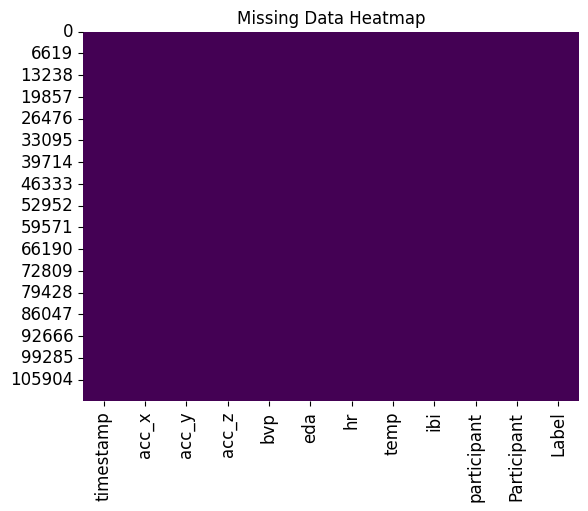

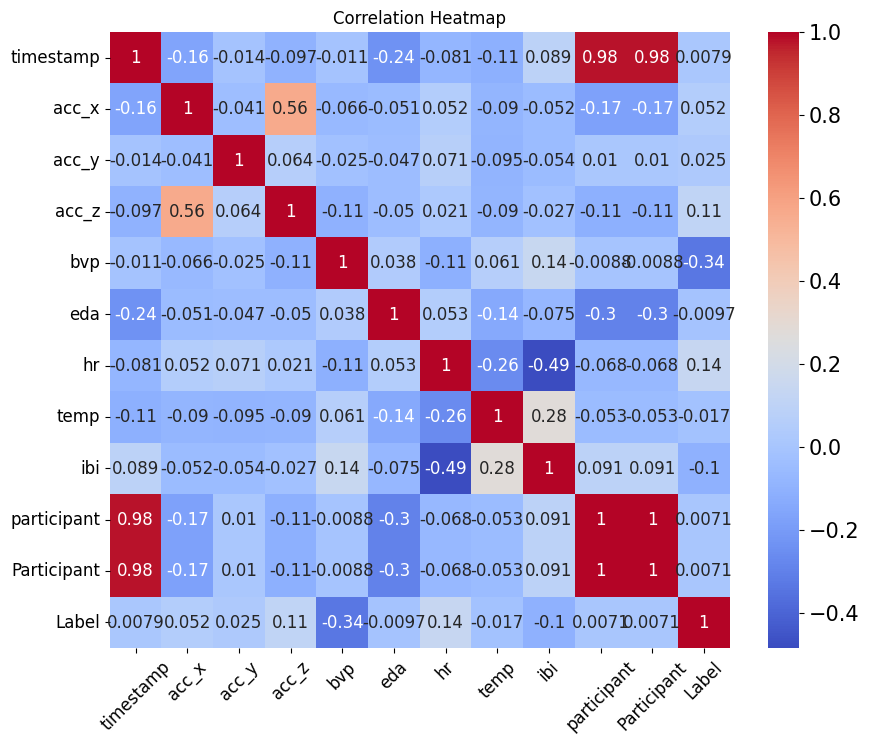

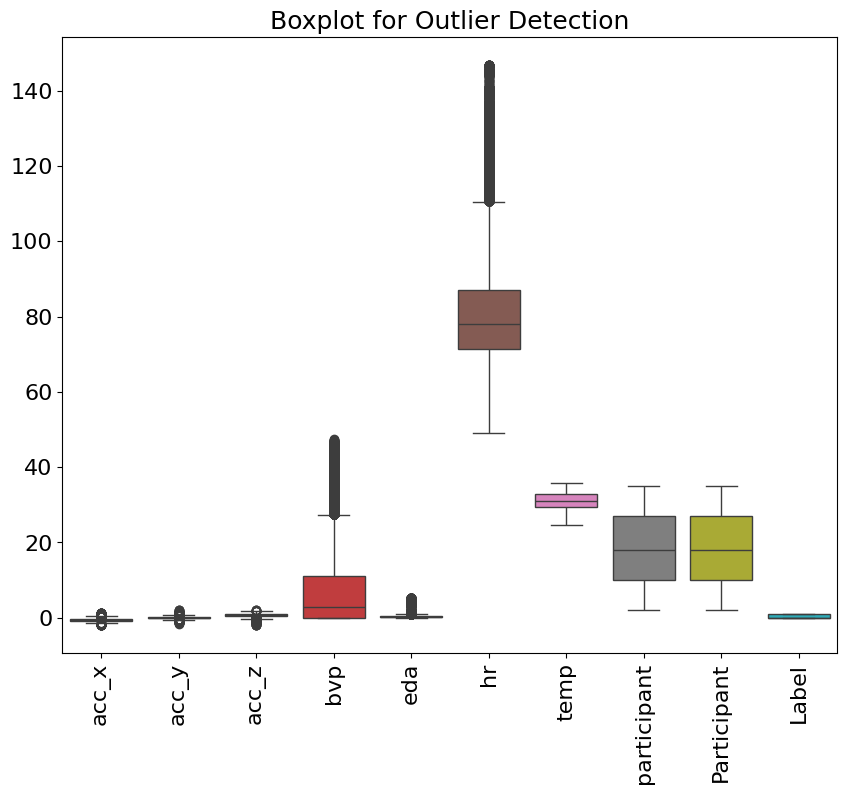

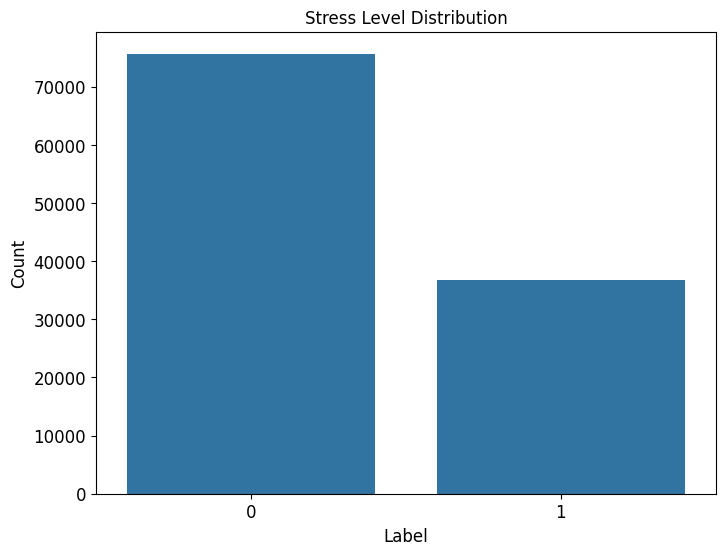

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set global font size
plt.rcParams.update({'font.size': 15})

# Basic Statistical Analysis
def basic_stats(data):
    print("Basic Statistics:")
    print(data.describe())

# Missing Value Analysis
def missing_values(data):
    print("\nMissing Values:")
    print(data.isnull().sum())
    sns.heatmap(data.isnull(), cmap='viridis', cbar=False)
    plt.title('Missing Data Heatmap', fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

# Correlation Heatmap
def plot_correlation(data):
    plt.figure(figsize=(10,8))
    sns.heatmap(data.corr(), annot=True, cmap='coolwarm', annot_kws={"size": 12})
    plt.title('Correlation Heatmap', fontsize=12)
    plt.xticks(fontsize=12, rotation=45)
    plt.yticks(fontsize=12, rotation=0)
    plt.show()

# Boxplots for Outlier Detection
def plot_boxplots(data):
    plt.figure(figsize=(10,8))
    sns.boxplot(data=data)
    plt.title('Boxplot for Outlier Detection', fontsize=18)
    plt.xticks(rotation=90, fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

# Visualizing Stress Labels
def plot_stress_labels(data):
    if 'Label' not in data.columns:
        print("No stress label found!")
        return
    plt.figure(figsize=(8,6))
    sns.countplot(x='Label', data=data)
    plt.title('Stress Level Distribution', fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel('Label', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()

# Example Usage
basic_stats(all_combined_data)
missing_values(all_combined_data)
plot_correlation(all_combined_data)
plot_boxplots(all_combined_data)
plot_stress_labels(all_combined_data)


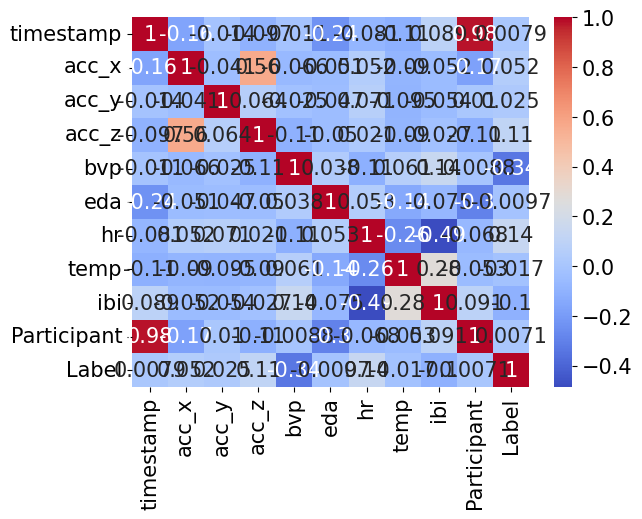

In [ ]:
all_combined_data1 = all_combined_data.drop(['participant'], axis=1)
# all_combined_data1 = all_combined_data1.drop(['Participant'], axis=1)
# all_combined_data1 = all_combined_data1.drop(['index'], axis=1)
# all_combined_data1 = all_combined_data1.drop(['Label'], axis=1)
# Get the correlation matrix
corr_matrix = all_combined_data1.corr()

# Plot a heatmap of the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

📊 Basic Statistics:
                            timestamp          acc_x          acc_y  \
count                          112508  112508.000000  112508.000000   
unique                            NaN            NaN            NaN   
top                               NaN            NaN            NaN   
freq                              NaN            NaN            NaN   
mean    2022-02-24 08:45:52.377271040      -0.539141      -0.023905   
min               2022-02-07 09:53:03      -2.000000      -1.656250   
25%     2022-02-14 13:38:57.750000128      -0.812500      -0.187500   
50%        2022-02-21 16:22:44.500000      -0.546875      -0.031250   
75%     2022-03-07 10:18:28.249999872      -0.328125       0.125000   
max               2022-03-09 16:10:46       1.328125       1.984375   
std                               NaN       0.338430       0.321364   

                acc_z            bvp            eda             hr  \
count   112508.000000  112508.000000  112508.000000  1125

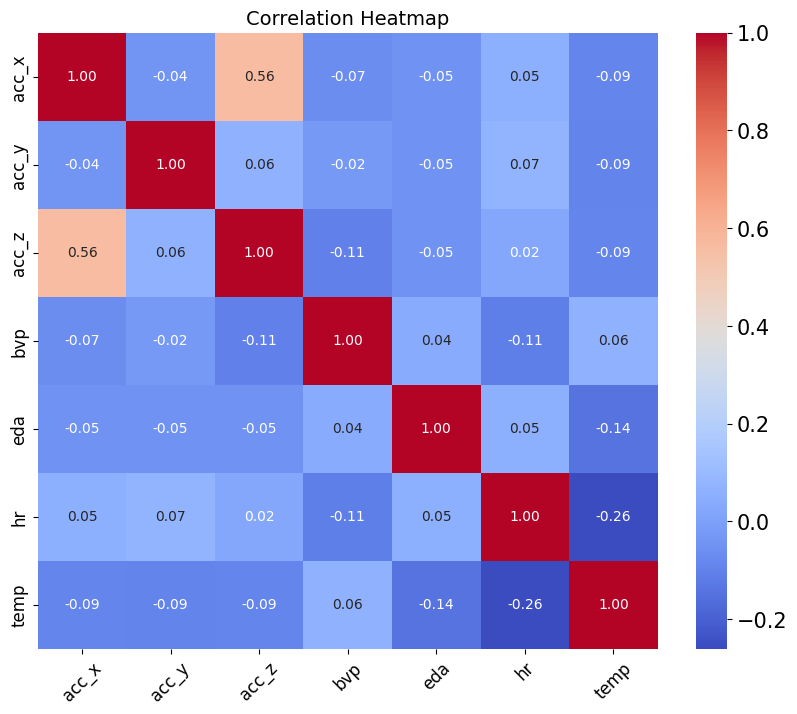

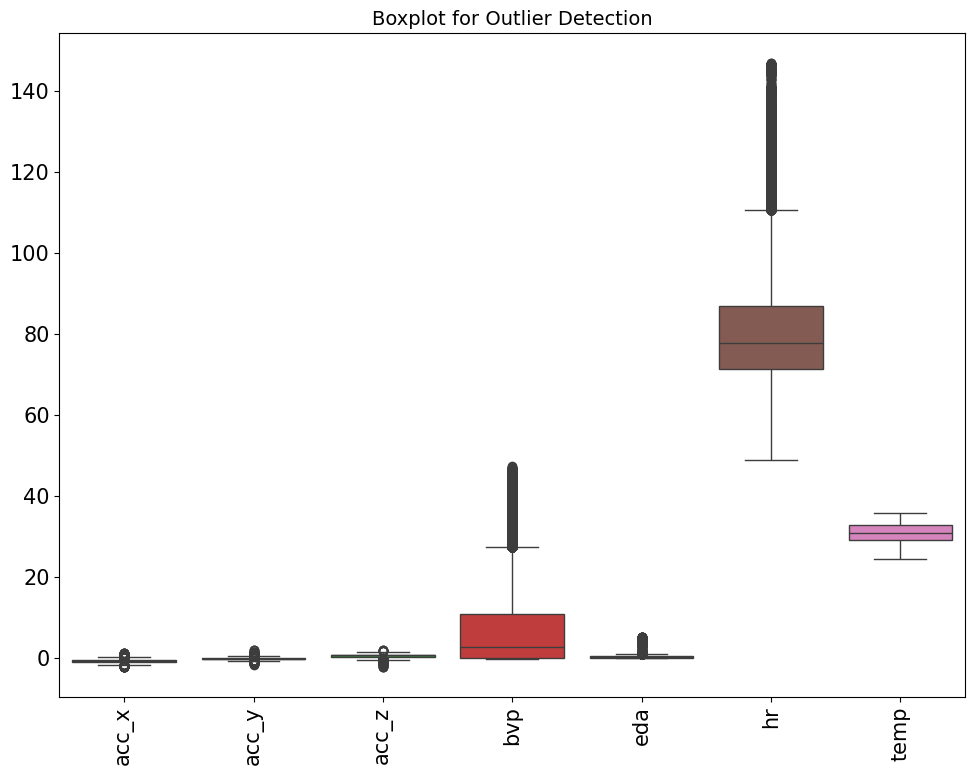

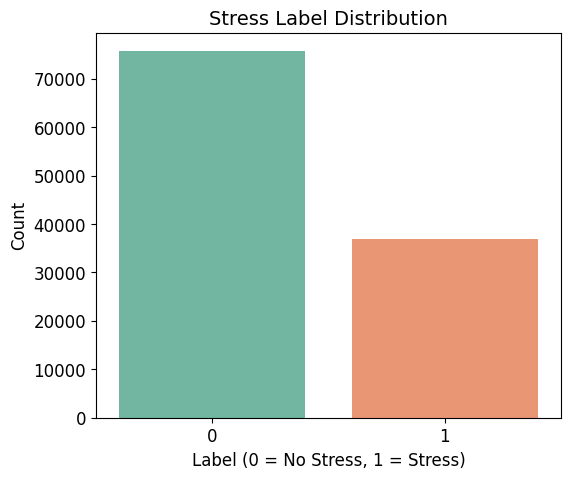

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set global font size
plt.rcParams.update({'font.size': 15})

# 1. Basic Statistical Analysis
def basic_stats(data):
    print("📊 Basic Statistics:")
    print(data.describe(include='all'))

# 2. Missing Value Analysis
def missing_values(data):
    print("\n🕳️ Missing Values:")
    missing = data.isnull().sum()
    print(missing[missing > 0])

    if missing.any():
        plt.figure(figsize=(12, 6))
        sns.heatmap(data.isnull(), cmap='viridis', cbar=False)
        plt.title('Missing Data Heatmap', fontsize=14)
        plt.xticks(rotation=45, fontsize=12)
        plt.yticks(fontsize=10)
        plt.show()
    else:
        print("No missing values found.")

# 3. Correlation Heatmap (only numeric columns)
def plot_correlation(data):
    numeric_data = data.select_dtypes(include=[np.number])
    exclude_cols = ['Label', 'participant', 'Participant']
    numeric_data = numeric_data.drop(columns=[col for col in exclude_cols if col in numeric_data.columns], errors='ignore')

    if numeric_data.shape[1] < 2:
        print("Not enough numeric columns for correlation heatmap.")
        return

    corr = numeric_data.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10})
    plt.title('Correlation Heatmap', fontsize=14)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

# 4. Boxplots for Outlier Detection (excluding non-sensor columns)
def plot_boxplots(data):
    numeric_data = data.select_dtypes(include=[np.number])
    exclude_cols = ['Label', 'participant', 'Participant']
    numeric_data = numeric_data.drop(columns=[col for col in exclude_cols if col in numeric_data.columns], errors='ignore')

    if numeric_data.empty:
        print("No valid numeric columns for boxplot.")
        return

    plt.figure(figsize=(10, 8))
    sns.boxplot(data=numeric_data)
    plt.title('Boxplot for Outlier Detection', fontsize=14)
    plt.xticks(rotation=90, fontsize=15)
    plt.yticks(fontsize=15)
    plt.tight_layout()
    plt.show()

# 5. Visualizing Stress Labels
def plot_stress_labels(data):
    if 'Label' not in data.columns:
        print("No 'Label' column found!")
        return

    plt.figure(figsize=(6, 5))
    sns.countplot(x='Label', data=data, palette='Set2')
    plt.title('Stress Label Distribution', fontsize=14)
    plt.xlabel('Label (0 = No Stress, 1 = Stress)', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

# 6. Run Full EDA Pipeline
def run_full_eda(data):
    basic_stats(data)
    missing_values(data)
    plot_correlation(data)
    plot_boxplots(data)
    plot_stress_labels(data)

# ✅ Example usage:
# run_full_eda(all_combined_data)
run_full_eda(all_combined_data)


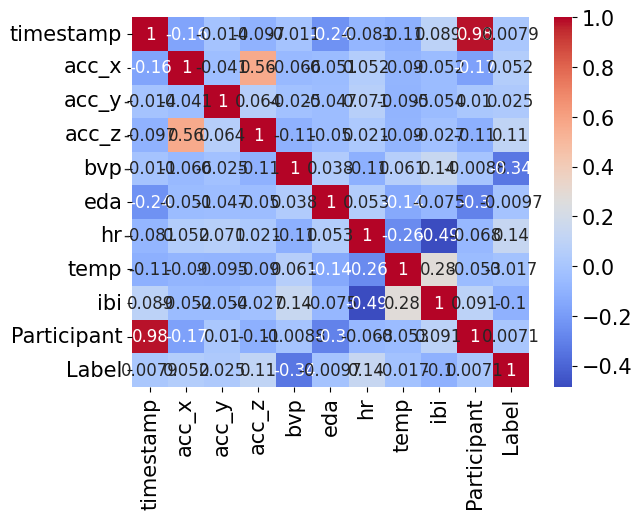

In [ ]:
# Get the correlation matrix
corr_matrix = all_combined_data1.corr()

# Plot a heatmap of the correlation matrix
# Pass font size within annot_kws
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', annot_kws={'fontsize': 12})
plt.show()

In [ ]:
# acc_x	acc_y	acc_z	bvp	eda	hr	ibi	temp	participant	Participant	Label
# FeatureSet 1 - BVP, IDI, HR
fs1 = all_combined_data[['eda', 'temp', 'Label']]
fs1 = fs1.dropna()
fs1 = fs1.reset_index(drop=True)

fs2 = all_combined_data[['bvp', 'eda','hr', 'Label']]
fs2 = fs2.dropna()
fs2 = fs2.reset_index(drop=True)


sns.countplot(x = fs1['Label'])

In [ ]:


df_inp_A = fs1[fs1['Label'] == 0]
df_inp_B = fs1[fs1['Label'] == 1]

n = df_inp_B['Label'].value_counts()
df_inp_A = df_inp_A.sample(frac = 0.5)
print(df_inp_A['Label'].value_counts(), df_inp_B['Label'].value_counts())
fs1 = pd.concat([df_inp_A, df_inp_B])

sns.countplot(x = fs1['Label'])

In [ ]:
fs1.head()

In [ ]:
all_combined_data.head()

In [ ]:
import numpy as np
import pandas as pd

def add_acceleration_features(df):
    # Calculate acceleration magnitude
    df['acc_magnitude'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

    # Rolling statistics for acceleration
    window_size = 5
    for axis in ['acc_x', 'acc_y', 'acc_z', 'acc_magnitude']:
        df[f'{axis}_mean'] = df[axis].rolling(window=window_size).mean()
        df[f'{axis}_std'] = df[axis].rolling(window=window_size).std()

    return df

def add_physiological_features(df):
    # Heart Rate Variability (HRV) using IBI data
    df['hrv'] = df['ibi'].rolling(window=5).std()

    # Statistical features for BVP, HR, and EDA
    for col in ['bvp', 'hr', 'eda']:
        df[f'{col}_mean'] = df[col].rolling(window=5).mean()
        df[f'{col}_std'] = df[col].rolling(window=5).std()

    return df

def add_time_features(df):
    # Ensure timestamps are valid
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors='coerce')

    # Check for invalid timestamps
    if df.index.isnull().any():
        print("Warning: Null timestamps detected.")
    else:
        print("Timestamps are valid.")

    # Extract time-based features
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_daytime'] = ((df['hour'] >= 6) & (df['hour'] <= 18)).astype(int)

    return df

def perform_feature_engineering(df):
    df = add_acceleration_features(df)
    df = add_physiological_features(df)
    df = add_time_features(df)

    # Handle missing values
    df = df.fillna(method='bfill').fillna(method='ffill')

    return df

# Ensure timestamp is properly set before starting
if not isinstance(all_combined_data.index, pd.DatetimeIndex):
    all_combined_data.index = pd.to_datetime(all_combined_data.index, errors='coerce')

# Perform feature engineering
all_combined_data = perform_feature_engineering(all_combined_data)

# Final data check
print("Final Data Shape:", all_combined_data.shape)
print("Missing Values:")
print(all_combined_data.isnull().sum())

# Preview the final dataset
print(all_combined_data.head())


In [ ]:
# Keep only the original columns
original_columns = ['index','timestamp', 'acc_x', 'acc_y', 'acc_z', 'bvp', 'eda', 'hr', 'temp', 'ibi', 'participant']
all_combined_data = all_combined_data[original_columns]

print("Shape after removing additional columns:", all_combined_data.shape)
print(all_combined_data.head())


In [ ]:
# Reset index to remove the extra timestamp
all_combined_data = all_combined_data.reset_index(drop=True)

print("Shape after resetting index:", all_combined_data.shape)
print(all_combined_data.head())


In [ ]:
import numpy as np
import pandas as pd

def add_acceleration_features(df):
    # Calculate acceleration magnitude
    df['acc_magnitude'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

    # Rolling statistics for acceleration
    window_size = 5
    for axis in ['acc_x', 'acc_y', 'acc_z', 'acc_magnitude']:
        df[f'{axis}_mean'] = df[axis].rolling(window=window_size).mean()
        df[f'{axis}_std'] = df[axis].rolling(window=window_size).std()

    return df

def add_physiological_features(df):
    # Heart Rate Variability (HRV) using IBI data
    df['hrv'] = df['ibi'].rolling(window=5).std()

    # Statistical features for BVP, HR, and EDA
    for col in ['bvp', 'hr', 'eda']:
        df[f'{col}_mean'] = df[col].rolling(window=5).mean()
        df[f'{col}_std'] = df[col].rolling(window=5).std()

    return df

def add_time_features(df):
    # Extract time-based features
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_daytime'] = ((df['hour'] >= 6) & (df['hour'] <= 18)).astype(int)

    return df

def perform_feature_engineering(df):
    df = add_acceleration_features(df)
    df = add_physiological_features(df)
    # df = add_time_features(df)

    # Fill any remaining NaN values
    df = df.fillna(method='bfill').fillna(method='ffill')
    return df

# Example Usage
all_combined_data = perform_feature_engineering(all_combined_data)
print(all_combined_data.head())


In [ ]:
all_combined_data.columns

In [ ]:
X = all_combined_data.drop(['participant','Participant', 'timestamp', 'Label'], axis=1)
y = all_combined_data['Label']


In [ ]:
X

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation_matrix = all_combined_data.corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Identify highly correlated features (Threshold = 0.9)
thresh = 0.9
highly_correlated_features = set()

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > thresh:
            colname = correlation_matrix.columns[i]
            highly_correlated_features.add(colname)

print("Highly Correlated Features (Correlation > 0.9):")
print(highly_correlated_features)

# Drop the correlated features
df_selected = all_combined_data.drop(columns=highly_correlated_features)

print("Shape after feature selection:", df_selected.shape)


## Model Training

In [ ]:
y = all_combined_data['Label']
y

,Label
0,0
1,0
2,0
3,0
4,0
...,...
112503,0
112504,0
112505,0
112506,0


In [ ]:
X = all_combined_data.drop(['Participant','participant', 'timestamp','Label'], axis=1)
X

,acc_x,acc_y,acc_z,bvp,eda,hr,temp,ibi
0,-0.453125,0.062500,0.890625,0.000000,0.790695,118.00,34.790,0.687500
1,-0.437500,0.093750,0.890625,0.000000,0.821516,118.00,34.790,0.687500
2,-0.312500,0.046875,0.953125,0.000000,0.852336,113.50,34.790,0.687500
3,-0.656250,-0.406250,0.812500,0.000000,0.883157,93.00,34.790,0.687500
4,-0.968750,-0.187500,-0.156250,0.000000,0.823892,93.25,34.790,0.687500
...,...,...,...,...,...,...,...,...
112503,-0.265625,-0.109375,0.968750,42.392187,0.480766,65.37,33.540,1.015625
112504,-0.296875,-0.078125,0.937500,42.466094,0.480766,65.42,33.535,1.015625
112505,-0.281250,-0.015625,0.968750,42.540000,0.480766,65.45,33.530,1.015625
112506,-0.250000,0.000000,0.968750,42.627656,0.480446,65.47,33.530,1.015625


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming 'participant' is the label column
# X = all_combined_data.drop(['participant','participant', 'timestamp','Label'], axis=1)
# y = all_combined_data['Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict on the test data
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.99

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     22736
           1       0.99      0.98      0.99     11017

    accuracy                           0.99     33753
   macro avg       0.99      0.99      0.99     33753
weighted avg       0.99      0.99      0.99     33753


Confusion Matrix:
[[22670    66]
 [  176 10841]]


In [ ]:
# Predict on the training data
y_train_pred = rf_model.predict(X_train_scaled)

# Print the classification report for the training data
print("Random Forest Classification Report (Training Data):")
print(classification_report(y_train, y_train_pred))

# Print the classification report for the testing data (already calculated in the previous step)
print("\nRandom Forest Classification Report (Testing Data):")
print(classification_report(y_test, y_pred))

Random Forest Classification Report (Training Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     52957
           1       1.00      1.00      1.00     25798

    accuracy                           1.00     78755
   macro avg       1.00      1.00      1.00     78755
weighted avg       1.00      1.00      1.00     78755


Random Forest Classification Report (Testing Data):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     22736
           1       0.99      0.98      0.99     11017

    accuracy                           0.99     33753
   macro avg       0.99      0.99      0.99     33753
weighted avg       0.99      0.99      0.99     33753



In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy')
print(f"Cross-validation Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.98)  # Keep 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming 'participant' is the label column
# X = all_combined_data.drop(['participant','participant', 'timestamp','Label'], axis=1)
# y = all_combined_data['Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_pca, y_train)

# Predict on the test data
y_pred = rf_model.predict(X_test_pca)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for class 1 (stress)
y_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

# Compute precision-recall pairs and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

# Automatically choose best threshold for max recall (with minimum acceptable precision)
min_precision = 0.90
valid_idxs = np.where(precision[:-1] >= min_precision)[0]  # exclude last threshold (no threshold)

if valid_idxs.size > 0:
    best_idx = valid_idxs[np.argmax(recall[valid_idxs])]
    best_threshold = thresholds[best_idx]

    print(f"✅ Best Threshold (precision ≥ {min_precision}): {best_threshold:.2f}")
    print(f"Precision: {precision[best_idx]:.4f}, Recall: {recall[best_idx]:.4f}")

    # Apply the best threshold
    y_pred_thresh = (y_probs >= best_threshold).astype(int)

    # Print all relevant metrics
    accuracy = accuracy_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    f2 = fbeta_score(y_test, y_pred_thresh, beta=2)
    roc = roc_auc_score(y_test, y_probs)

    print(f"\n📊 Final Evaluation at Optimal Threshold ({best_threshold:.2f}):")
    print(f"Accuracy     : {accuracy:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"F2 Score     : {f2:.4f}")
    print(f"ROC AUC Score: {roc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_thresh))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresh))

else:
    print(f"⚠️ Warning: No threshold found with precision >= {min_precision}.")
    print("Using default threshold of 0.5 for evaluation.")

    # Use a default threshold (e.g., 0.5) if no threshold meets the minimum precision
    best_threshold = 0.5
    y_pred_thresh = (y_probs >= best_threshold).astype(int)

    # Print all relevant metrics using the default threshold
    accuracy = accuracy_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    f2 = fbeta_score(y_test, y_pred_thresh, beta=2)
    roc = roc_auc_score(y_test, y_probs) # ROC AUC score is independent of threshold

    print(f"\n📊 Final Evaluation at Default Threshold ({best_threshold:.2f}):")
    print(f"Accuracy     : {accuracy:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"F2 Score     : {f2:.4f}")
    print(f"ROC AUC Score: {roc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_thresh))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_thresh))

In [ ]:
import seaborn as sns
sns.histplot(y_probs, bins=50, kde=True)
plt.title("Distribution of Predicted Probabilities for Class 1 (Stress)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.grid()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Define a range of thresholds to tune
thresholds = np.arange(0.1, 1.0, 0.05)  # Example: from 0.1 to 0.95 with step 0.05

best_threshold = 0
best_metric_value = 0  # Initialize with a value that will be easily surpassed

# Predict probabilities on the test set
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]  # Get probabilities for the positive class

# Iterate through thresholds and evaluate performance
for threshold in thresholds:
    # Predict labels based on the current threshold
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    # Calculate your desired evaluation metric (e.g., F1-score)
    current_metric_value = f1_score(y_test, y_pred_threshold)

    # Check if the current threshold gives better performance
    if current_metric_value > best_metric_value:
        best_metric_value = current_metric_value
        best_threshold = threshold

print(f"Best Threshold: {best_threshold}")
print(f"Best Metric Value (F1-score): {best_metric_value}")

# Use the best threshold to make final predictions on the test set
final_predictions = (y_pred_proba >= best_threshold).astype(int)

# Evaluate the final predictions with the best threshold
print("\nEvaluation with Best Threshold:")
print(f"Accuracy: {accuracy_score(y_test, final_predictions)}")
print(f"Precision: {precision_score(y_test, final_predictions)}")
print(f"Recall: {recall_score(y_test, final_predictions)}")
print(f"F1-score: {f1_score(y_test, final_predictions)}")

# You can also print the classification report and confusion matrix
print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

In [ ]:
import matplotlib.pyplot as plt

pca_full = PCA().fit(X_train_scaled)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming 'participant' is the label column
# X = all_combined_data.drop(['participant','participant', 'timestamp','Label'], axis=1)
# y = all_combined_data['Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict on the test data
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, classification_report, confusion_matrix, precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# === STEP 1: Split Your Data ===
# X = all_combined_data.drop(['participant', 'timestamp', 'Label'], axis=1)
# y = all_combined_data['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# === STEP 2: Define Pipeline ===
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

# === STEP 3: Fit Pipeline ===
pipeline.fit(X_train, y_train)

# === STEP 4: Calibrate Probabilities ===
calibrated_rf = CalibratedClassifierCV(pipeline.named_steps['rf'], method='sigmoid', cv=5)
X_train_scaled = pipeline.named_steps['scaler'].transform(X_train)
calibrated_rf.fit(X_train_scaled, y_train)

# === STEP 5: Predict Probabilities ===
X_test_scaled = pipeline.named_steps['scaler'].transform(X_test)
y_probs = calibrated_rf.predict_proba(X_test_scaled)[:, 1]

# === STEP 6: Plot Precision-Recall Curve ===
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

# === STEP 7: Threshold Tuning for Best F2 Score ===
best_f2, best_threshold = 0, 0.5
for t in thresholds:
    preds = (y_probs >= t).astype(int)
    f2 = fbeta_score(y_test, preds, beta=2)
    if f2 > best_f2:
        best_f2 = f2
        best_threshold = t

print(f"\n🎯 Best Threshold for F2: {best_threshold:.2f}, F2 Score: {best_f2:.4f}")

# === STEP 8: Final Evaluation ===
final_preds = (y_probs >= best_threshold).astype(int)

print("\n📊 Final Evaluation:")
print(f"Accuracy     : {accuracy_score(y_test, final_preds):.4f}")
print(f"Precision    : {precision_score(y_test, final_preds):.4f}")
print(f"Recall       : {recall_score(y_test, final_preds):.4f}")
print(f"F1 Score     : {f1_score(y_test, final_preds):.4f}")
print(f"F2 Score     : {fbeta_score(y_test, final_preds, beta=2):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, final_preds))
print("Confusion Matrix:")
print(confusion_matrix(y_test, final_preds))


In [ ]:
# Evaluate on training data
y_train_probs = calibrated_rf.predict_proba(X_train_scaled)[:, 1]
y_train_preds = (y_train_probs >= 0.11).astype(int)

from sklearn.metrics import fbeta_score
train_f2 = fbeta_score(y_train, y_train_preds, beta=2)
print(f"Training F2 Score: {train_f2:.4f}")


In [ ]:
# Check label distribution in training and testing sets
train_label_counts = pd.Series(y_train).value_counts()
test_label_counts = pd.Series(y_test).value_counts()

print("Label Distribution in Training Set:")
print(train_label_counts)

print("\nLabel Distribution in Testing Set:")
print(test_label_counts)

# Alternatively using numpy
print("\nUsing Numpy:")
print("Training Set - 0s and 1s:", np.bincount(y_train))
print("Testing Set - 0s and 1s:", np.bincount(y_test))


In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
# Train SVM classifier
svm_model = SVC(kernel='rbf', probability=True)  # You can also try 'linear', 'poly'
svm_model.fit(X_train_scaled, y_train)

# Predict
svm_preds = svm_model.predict(X_test_scaled)

# Evaluate
print("SVM Model Results")
print(confusion_matrix(y_test, svm_preds))
print(classification_report(y_test, svm_preds))
print("Accuracy:", accuracy_score(y_test, svm_preds))


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib # Import joblib for saving and loading models

# Assuming 'participant' is the label column
# X = all_combined_data.drop(['participant','participant', 'timestamp','Label'], axis=1)
# y = all_combined_data['Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Save the trained model to a file
joblib.dump(rf_model, 'random_forest_model.pkl')

# Save the scaler to a file
joblib.dump(scaler, 'scaler.pkl')

# Predict on the test data
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [ ]:
import matplotlib
import seaborn as sns
import pandas as pd
import numpy as np
import sklearn
import flask
import joblib
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Flask version: {flask.__version__}")
print(f"Joblib version: {joblib.__version__}")


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import accuracy_score, classification_report

# Define the model
rf = RandomForestClassifier(random_state=42)

# Optimized Hyperparameter grid
param_dist = {
    'n_estimators': randint(50, 150),
    'max_depth': randint(10, 60),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2']
}

# RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,  # Reduced from 50 to 30
    scoring='accuracy',
    cv=3,  # Reduced from 5 to 3
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit the model
random_search.fit(X_train, y_train)

# Best parameters and model
print("Best Parameters:", random_search.best_params_)
best_rf = random_search.best_estimator_

# Evaluate on test data
y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


In [ ]:
print(9)

#### Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Handle missing values
data = fs1.dropna()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data.drop('Label', axis=1), data['Label'], test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a logistic regression model
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, y_train)

# Evaluate the model's performance on the testing set
y_pred = model_lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

##### Hyper Tuning

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define hyperparameters and their potential values
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

# Create a logistic regression model
model = LogisticRegression()

# Create a grid search object
grid_search = GridSearchCV(model, param_grid, cv=5)

# Fit the grid search object to the data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and their performance on the validation set
print('Best hyperparameters:', grid_search.best_params_)
print('Validation accuracy:', grid_search.best_score_)

In [ ]:
# From hyper params
best_c = 10
best_penalty = 'l1'
best_solver = 'liblinear'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Handle missing values
data = fs1.dropna()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data.drop('Label', axis=1), data['Label'], test_size=0.2, random_state=56)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a logistic regression model
model_lr = LogisticRegression(C=best_c, penalty=best_penalty, solver=best_solver)
model_lr.fit(X_train, y_train)

# Evaluate the model's performance on the testing set
y_pred = model_lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#### Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


data = fs1.dropna()

# Separate features and labels
X = data.drop(columns=['Label'])
y = data['Label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit the model
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = model_nb.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot confusion matrix as heatmap
sns.heatmap(cm, annot=True, cmap='Blues')


#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# data = fs1.dropna()

# # define X and y
# X = data.drop('Label', axis=1)
# y = data['Label']

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# create a random forest classifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# train the model on the training data
model_rf.fit(X_train, y_train)

# make predictions on the testing data
y_pred = model_rf.predict(X_test)

# evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

## Model Comparison

#### Accuracy Comparison

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create and fit the models
# model_nb = Naive Bayes
# model_lr = Logistic Regression
# model_rf = Random Forest
# X_train and y_train are the training data and labels
# X_test and y_test are the testing data and labels
model_nb.fit(X_train, y_train)
model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

# Predict on the testing data
y_pred_1 = model_nb.predict(X_test)
y_pred_2 = model_lr.predict(X_test)
y_pred_3 = model_rf.predict(X_test)

# Calculate and print accuracy scores
acc_score_1 = accuracy_score(y_test, y_pred_1)
acc_score_2 = accuracy_score(y_test, y_pred_2)
acc_score_3 = accuracy_score(y_test, y_pred_3)
print("Accuracy score of Naive Bayes model: ", acc_score_1)
print("Accuracy score of Logistic Regression model: ", acc_score_2)
print("Accuracy score of Random Forest model: ", acc_score_3)


# plt.figure(figsize=(8,4))
# plt.show()

#### Accuracy Plot

In [ ]:
# model_nb = Naive Bayes
# model_lr = Logistic Regression
# model_rf = Random Forest
import matplotlib.pyplot as plt # Import matplotlib.pyplot and rename to plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = ['Random Forest', 'Logistic Regression', 'Naive Bayes','MLP Neural Net','XGBoost','LightGBM']
#The accuracies list had 7 items when it should have had 6 to match the number of items in the models list
accuracies = [99, 64.25, 65.31,95.69,96,97] #Removed the extra value (91)

# Define color palette
# colors = ['#FFA69E', '#C9DECB', '#86C6A7']

# create the bar plot
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(models, accuracies)

# set chart title and labels
ax.set_title('Comparison of Classification Model Accuracies')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')

# display the plot
plt.show()

#### Confusion Matix Comparison

In [ ]:
# Define a function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title):
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in zip(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Calculate and plot confusion matrices
cm_1 = confusion_matrix(y_test, y_pred_1)
cm_2 = confusion_matrix(y_test, y_pred_2)
cm_3 = confusion_matrix(y_test, y_pred_3)

plot_confusion_matrix(cm_1, [0,1], 'Naive Bayes')
plt.show()

plot_confusion_matrix(cm_2, [0,1], 'Logistic Regression')
plt.show()

plot_confusion_matrix(cm_3, [0,1], 'Random Forest')
plt.show()


#### Classification Report Comparison

In [ ]:

# Calculate and plot confusion matrices
cm_1 = classification_report(y_test, y_pred_1)
cm_2 = classification_report(y_test, y_pred_2)
cm_3 = classification_report(y_test, y_pred_3)

print("Naive Bayes")
print(cm_1)
print('--'*30,'\nLogistic Regression')
print(cm_2)
print('--'*30,'\nRandom Forest')
print(cm_3)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import numpy as np

# Predict on test data
y_pred = best_rf.predict(X_test)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC Curve (for multi-class using OneVsRest strategy)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarize labels for multi-class ROC
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_prob = best_rf.predict_proba(X_test)

# Calculate AUC for each class
auc_scores = []
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Feature importance plot
feature_importances = best_rf.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(12,8))
sns.barplot(x=feature_importances[sorted_indices], y=np.array(X_train.columns)[sorted_indices], palette='viridis')
plt.title('Feature Importances')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import numpy as np

# Predict on test data
y_pred = rf_model.predict(X_test)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC Curve (for multi-class using OneVsRest strategy)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarize labels for multi-class ROC
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_prob = best_rf.predict_proba(X_test)

# Check if y_test_bin has more than one column
if y_test_bin.shape[1] > 1:
    # Calculate AUC for each class if y_test_bin has multiple columns
    auc_scores = []
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')
else:
    # If y_test_bin has only one column, it's a binary classification
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_prob[:, 1]) # Use ravel() and access the second column of y_pred_prob
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {classes[1]} (AUC = {roc_auc:.2f})') # Plot for the positive class (class 1)

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve') # Changed title to "ROC Curve"
plt.legend(loc='lower right')
plt.show()

# Feature importance plot
feature_importances = best_rf.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(12,8))
sns.barplot(x=feature_importances[sorted_indices], y=np.array(X_train.columns)[sorted_indices], palette='viridis')
plt.title('Feature Importances')
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(random_state=42, n_estimators=200, learning_rate=0.05, max_depth=5)
gb_classifier.fit(X_train_scaled, y_train)

# Predictions
y_pred = gb_classifier.predict(X_test_scaled)
y_pred_proba = gb_classifier.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate ROC AUC only if the problem is binary classification
if len(set(y_test)) == 2:
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print("ROC AUC Score:", roc_auc)


In [ ]:
import joblib

# Save Gradient Boosting model
joblib.dump(gb_classifier, 'gradient_boosting_model.pkl')
print("Gradient Boosting model saved as gradient_boosting_model.pkl")

# Save Random Forest model
joblib.dump(best_rf, 'random_forest_model.pkl')
print("Random Forest model saved as random_forest_model.pkl")

# Load the models (if needed)
loaded_gb = joblib.load('gradient_boosting_model.pkl')
loaded_rf = joblib.load('random_forest_model.pkl')
print("Models loaded successfully")


In [ ]:
!pip install streamlit
import streamlit as st
import joblib
import numpy as np

# Load models
gb_model = joblib.load('gradient_boosting_model.pkl')
rf_model = joblib.load('random_forest_model.pkl')

st.title("Stress Analysis Prediction")

# Input features
st.sidebar.write("Enter Features:")
features = [st.sidebar.number_input(f'Feature {i+1}') for i in range(24)]
model_choice = st.sidebar.selectbox("Choose Model", ['Random Forest', 'Gradient Boosting'])

if st.button("Predict"):
    try:
        features = np.array(features).reshape(1, -1)
        model = gb_model if model_choice == 'Gradient Boosting' else rf_model
        prediction = model.predict(features)
        st.success(f'Prediction: {prediction[0]}')
    except Exception as e:
        st.error(f"Error: {str(e)}")


In [ ]:
/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py

In [ ]:
!pip install flask
!pip install pyngrok


In [ ]:
import joblib
import numpy as np
from flask import Flask, request, jsonify

# Load models
rf_model = joblib.load('random_forest_model.pkl')
gb_model = joblib.load('gradient_boosting_model.pkl')

app = Flask(__name__)

@app.route('/')
def home():
    return "Welcome to the Stress Analysis Prediction API!"

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        features = np.array(data['features']).reshape(1, -1)
        model_choice = data.get('model', 'random_forest')

        if model_choice == 'gradient_boosting':
            prediction = gb_model.predict(features)
        else:
            prediction = rf_model.predict(features)

        return jsonify({'prediction': int(prediction[0])})
    except Exception as e:
        return jsonify({'error': str(e)})

if __name__ == "__main__":
    app.run(port=5000)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Gradient Boosting Models
import xgboost as xgb
import lightgbm as lgb

# Load dataset
# df = pd.read_csv("your_dataset.csv")  # Replace with your actual CSV filename

# # Separate features and target
# X = df.drop("label", axis=1)
# y = df["label"]

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Feature Scaling
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Dictionary of models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=300),
    # "SVM": SVC(kernel='rbf', probability=True),
    "Naive Bayes": GaussianNB(),
    "MLP Neural Net": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, activation='relu', random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": lgb.LGBMClassifier()
}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# Load dataset
# df = pd.read_csv("your_dataset.csv")  # Replace with your actual file path

# # Features & label
# X = df.drop("label", axis=1)
# y = df["label"]
feature_names = X.columns

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Scale data
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)

# Tree-based models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": lgb.LGBMClassifier()
}

# Plot feature importances
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 5))
        sns.barplot(x=importances[indices], y=feature_names[indices])
        plt.title(f"{name} - Feature Importance", fontsize=15)
        plt.xlabel("Importance Score", fontsize=15)
        plt.ylabel("Feature", fontsize=15)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.grid(axis="x", linestyle="--", linewidth=0.5)
        plt.tight_layout()
        plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

import xgboost as xgb
import lightgbm as lgb

# Load dataset
# df = pd.read_csv("your_dataset.csv")  # Replace with your actual file

# # Features & labels
# X = df.drop("label", axis=1)
# y = df["label"]

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Standardize
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=300),
    # "SVM": SVC(kernel='rbf', probability=True),
    "Naive Bayes": GaussianNB(),
    "MLP Neural Net": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": lgb.LGBMClassifier()
}

accuracies = {}
plt.figure(figsize=(10, 8))

# ROC Curve Plotting
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    # ROC Curve
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt_cm = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt_cm.set_title(f'Confusion Matrix - {name}')
    plt_cm.set_xlabel("Predicted")
    plt_cm.set_ylabel("Actual")
    plt.show()

# ROC curve plot
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Accuracy bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0.5, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


# Task
Analyze the provided codebase to identify potential overfitting in the model, and suggest and implement improvements to mitigate it, aiming for better generalization while maintaining good performance.

## Analyze current model performance

### Subtask:
Examine the classification report and confusion matrix for the Random Forest model to understand where it might be performing exceptionally well (or poorly).


**Reasoning**:
Print the classification report and confusion matrix for the Random Forest model to analyze its performance and check for signs of overfitting based on the provided `y_test` and `y_pred` variables.



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

**Reasoning**:
The previous attempt failed because `y_test` and `y_pred` were not defined in the current session. I need to re-run the code that splits the data and trains the Random Forest model to have access to these variables.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Assuming 'all_combined_data' contains the features and 'Label' is the target
X = all_combined_data.drop(['participant','Participant', 'timestamp','Label'], axis=1)
y = all_combined_data['Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest Classifier with regularization hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,  # Limit the depth of trees
    min_samples_split=5, # Require more samples to split a node
    min_samples_leaf=3 # Require more samples in a leaf node
)
rf_model.fit(X_train_scaled, y_train)

# Predict on the test data
y_pred = rf_model.predict(X_test_scaled)

# Print the classification report and confusion matrix
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     22736
           1       0.95      0.92      0.94     11017

    accuracy                           0.96     33753
   macro avg       0.96      0.95      0.95     33753
weighted avg       0.96      0.96      0.96     33753


Random Forest Confusion Matrix:
[[22224   512]
 [  862 10155]]


# Task
Apply regularization techniques to XGBoost, MLP Neural Net, Naive Bayes, and SVM models to mitigate overfitting, compare their performance with the original models using a comparison table and visualizations, and recommend the best model for stress prediction.

## Implement and evaluate regularization for each algorithm

### Subtask:
Implement and evaluate regularization for each of the specified algorithms (XGBoost, MLP Neural Net, Naive Bayes, SVM), applying appropriate regularization techniques and evaluating their performance on the test set using relevant metrics (accuracy, precision, recall, F1-score).


**Reasoning**:
Implement and evaluate regularization for XGBoost, MLP Neural Net, Naive Bayes, and SVM models as instructed in the subtask.



In [ ]:
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# 1. XGBoost with Regularization
print("=== Regularized XGBoost ===")
xgb_classifier_reg = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=0.1, # L2 regularization
    gamma=0.5,      # Minimum loss reduction required to make a further partition
    subsample=0.8,  # Subsample ratio of the training instances
    colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_classifier_reg.fit(X_train_scaled, y_train)
y_pred_xgb_reg = xgb_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_reg))
if len(set(y_test)) == 2:
    y_pred_proba_xgb_reg = xgb_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_xgb_reg))

# 2. MLP Neural Net with Regularization (L2)
print("\n=== Regularized MLP Neural Net ===")
mlp_classifier_reg = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    activation='relu',
    alpha=0.001, # L2 regularization parameter
    random_state=42
)
mlp_classifier_reg.fit(X_train_scaled, y_train)
y_pred_mlp_reg = mlp_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_mlp_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_mlp_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp_reg))
if len(set(y_test)) == 2:
    y_pred_proba_mlp_reg = mlp_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_mlp_reg))

# 3. Naive Bayes with Regularization (var_smoothing)
print("\n=== Regularized Naive Bayes ===")
nb_classifier_reg = GaussianNB(var_smoothing=1e-9) # Default is 1e-9, can try larger values like 1e-8, 1e-7 etc.
nb_classifier_reg.fit(X_train_scaled, y_train)
y_pred_nb_reg = nb_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_nb_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_nb_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb_reg))
if len(set(y_test)) == 2:
    y_pred_proba_nb_reg = nb_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_nb_reg))

# 4. SVM with Regularization (C and gamma)
print("\n=== Regularized SVM ===")
svm_classifier_reg = SVC(
    kernel='rbf',
    probability=True,
    C=0.1,     # Regularization parameter, smaller values specify stronger regularization
    gamma='scale', # Kernel coefficient
    random_state=42
)
svm_classifier_reg.fit(X_train_scaled, y_train)
y_pred_svm_reg = svm_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_svm_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_svm_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_reg))
if len(set(y_test)) == 2:
    y_pred_proba_svm_reg = svm_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_svm_reg))

=== Regularized XGBoost ===


NameError: name 'X_train_scaled' is not defined

**Reasoning**:
The previous attempt failed because the scaled data `X_train_scaled` and `X_test_scaled`, as well as the split data `y_train` and `y_test`, were not defined in the current session. I need to re-run the data splitting and scaling steps before training the models.



In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Redefine the get_..._data functions if they are not in the current session
def get_acc_data(folder_path):
    filename = os.path.join(folder_path, 'ACC.csv')
    df = pd.read_csv(filename, header=None)
    initial_time = pd.to_datetime(df.iloc[0, 0], unit='s')
    sample_rate = float(df.iloc[1, 0])
    data = df.iloc[2:, :3].astype(float)
    time_interval = 1 / sample_rate
    time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{time_interval}S')
    data.index = time_index
    data.columns = ['acc_x', 'acc_y', 'acc_z']
    data /= 64.0
    return data

def get_bvp_data(folder_path):
    filename = os.path.join(folder_path, 'BVP.csv')
    df = pd.read_csv(filename, header=None)
    initial_time = pd.to_datetime(df.iloc[0, 0], unit='s')
    sample_rate = float(df.iloc[1, 0])
    data = df.iloc[2:,:]
    data = data.astype(float)
    time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{sample_rate:.0f}S')
    data.index = time_index
    data.columns = ['bvp']
    return data

def get_eda_data(folder_path):
    filename = os.path.join(folder_path, 'EDA.csv')
    df = pd.read_csv(filename, header=None)
    initial_time = pd.to_datetime(df.iloc[0, 0], unit='s')
    sample_rate = float(df.iloc[1, 0])
    data = df.iloc[2:,:]
    data = data.astype(float)
    time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{sample_rate:.0f}S')
    data.index = time_index
    data.columns = ['eda']
    return data

def get_hr_data(folder_path):
    filename = os.path.join(folder_path, 'HR.csv')
    df = pd.read_csv(filename, header=None)
    initial_time = pd.to_datetime(df.iloc[0, 0], unit='s')
    sample_rate = float(df.iloc[1, 0])
    data = df.iloc[2:,:]
    data = data.astype(float)
    time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{sample_rate:.0f}S')
    data.index = time_index
    data.columns = ['hr']
    return data

def get_ibi_data(folder_path):
    filename = os.path.join(folder_path, 'IBI.csv')
    df = pd.read_csv(filename, header=None, names=['time', 'ibi'])
    index_values = df.iloc[:1,:].values
    index = pd.to_datetime(index_values[0][0], unit='s')
    data = df.iloc[1:,:]
    data.index = pd.to_datetime(data['time'], unit='s', origin=index).dt.floor('s')
    data.drop('time', axis=1, inplace=True)
    return data

def get_temp_data(folder_path):
    filename = os.path.join(folder_path, 'TEMP.csv')
    df = pd.read_csv(filename, header=None)
    index_values = df.iloc[:2,:].values
    index = pd.to_datetime(index_values[0], unit='s')
    sample_rate = float(index_values[1,0])
    data = df.iloc[2:,:]
    data = data.astype(float)
    time_index = pd.date_range(start=index[0], periods=len(data), freq=f'{sample_rate:.0f}S')
    data.index = time_index
    data.columns = ['temp']
    return data


def merge_sensor_data(acc_data, bvp_data, eda_data, hr_data, ibi_data, temp_data):
    for df in [acc_data, bvp_data, eda_data, hr_data, ibi_data, temp_data]:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError("All dataframes must have a DatetimeIndex.")
        df.index.name = 'timestamp'

    merged_data = acc_data.join([bvp_data, eda_data, hr_data, temp_data], how='outer')

    merged_data = pd.merge_asof(
        merged_data.reset_index(),
        ibi_data.reset_index(),
        on='timestamp',
        direction='nearest'
    ).set_index('timestamp')

    merged_data = merged_data.sort_index().interpolate(method='time').ffill().bfill()
    return merged_data


def merge_all_participants(base_path):
    dfs = []
    for folder in os.listdir(base_path):
        if folder.startswith('S') and os.path.isdir(os.path.join(base_path, folder)):
            folder_path = os.path.join(base_path, folder)
            participant = int(folder[1:])

            df1 = get_acc_data(folder_path)
            df2 = get_bvp_data(folder_path)
            df3 = get_eda_data(folder_path)
            df4 = get_hr_data(folder_path)
            df5 = get_ibi_data(folder_path)
            df6 = get_temp_data(folder_path)

            merged_data = merge_sensor_data(df1, df2, df3, df4, df5, df6)
            merged_data['participant'] = participant
            dfs.append(merged_data)

    all_data = pd.concat(dfs)
    all_data.columns = ['acc_x', 'acc_y', 'acc_z'] + list(all_data.columns[3:])
    return all_data

def perform_feature_engineering(df):
    df['acc_magnitude'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    window_size = 5
    for axis in ['acc_x', 'acc_y', 'acc_z', 'acc_magnitude']:
        df[f'{axis}_mean'] = df[axis].rolling(window=window_size).mean()
        df[f'{axis}_std'] = df[axis].rolling(window=window_size).std()
    df['hrv'] = df['ibi'].rolling(window=5).std()
    for col in ['bvp', 'hr', 'eda']:
        df[f'{col}_mean'] = df[col].rolling(window=5).mean()
        df[f'{col}_std'] = df[col].rolling(window=5).std()
    df = df.fillna(method='bfill').fillna(method='ffill')
    return df


# Load and merge all raw data
path = "/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data"
all_raw_data = merge_all_participants(path)

# Load and process label data
label_data = pd.read_csv('/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Processed_data/Improved_All_Combined_hr_rsp_binary.csv')
label_data['timestamp'] = pd.to_datetime(label_data['Time(sec)'], unit='s')
label_data.drop(['HR', 'respr','Time(sec)'], axis=1, errors='ignore', inplace=True)

# Combine raw data and label data
combined_data_list = []
for i in range(2, 36):
    this_participant_label_data = label_data[label_data['Participant'] == i]
    this_participant_rawdata = all_raw_data[all_raw_data['participant'] == i]

    if not this_participant_label_data.empty and not this_participant_rawdata.empty:
        this_participant_rawdata = this_participant_rawdata.reset_index().rename(columns={'index': 'timestamp'})
        this_participant_rawdata['participant'] = i

        this_participant_label_data = this_participant_label_data.rename(columns={'Time(sec)': 'timestamp'})
        this_participant_label_data['participant'] = i

        this_participant_merged = pd.merge(
            this_participant_rawdata,
            this_participant_label_data,
            on=['timestamp', 'participant'],
            how='inner'
        )
        combined_data_list.append(this_participant_merged)

all_combined_data = pd.concat(combined_data_list, ignore_index=True)

# Perform feature engineering
all_combined_data = perform_feature_engineering(all_combined_data)

# Assuming 'all_combined_data' contains the features and 'Label' is the target
X = all_combined_data.drop(['participant','Participant', 'timestamp','Label'], axis=1)
y = all_combined_data['Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# 1. XGBoost with Regularization
print("=== Regularized XGBoost ===")
xgb_classifier_reg = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=0.1, # L2 regularization
    gamma=0.5,      # Minimum loss reduction required to make a further partition
    subsample=0.8,  # Subsample ratio of the training instances
    colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_classifier_reg.fit(X_train_scaled, y_train)
y_pred_xgb_reg = xgb_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_reg))
if len(set(y_test)) == 2:
    y_pred_proba_xgb_reg = xgb_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_xgb_reg))

# 2. MLP Neural Net with Regularization (L2)
print("\n=== Regularized MLP Neural Net ===")
mlp_classifier_reg = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    activation='relu',
    alpha=0.001, # L2 regularization parameter
    random_state=42
)
mlp_classifier_reg.fit(X_train_scaled, y_train)
y_pred_mlp_reg = mlp_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_mlp_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_mlp_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp_reg))
if len(set(y_test)) == 2:
    y_pred_proba_mlp_reg = mlp_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_mlp_reg))

# 3. Naive Bayes with Regularization (var_smoothing)
print("\n=== Regularized Naive Bayes ===")
nb_classifier_reg = GaussianNB(var_smoothing=1e-9) # Default is 1e-9, can try larger values like 1e-8, 1e-7 etc.
nb_classifier_reg.fit(X_train_scaled, y_train)
y_pred_nb_reg = nb_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_nb_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_nb_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb_reg))
if len(set(y_test)) == 2:
    y_pred_proba_nb_reg = nb_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_nb_reg))

# 4. SVM with Regularization (C and gamma)
print("\n=== Regularized SVM ===")
svm_classifier_reg = SVC(
    kernel='rbf',
    probability=True,
    C=0.1,     # Regularization parameter, smaller values specify stronger regularization
    gamma='scale', # Kernel coefficient
    random_state=42
)
svm_classifier_reg.fit(X_train_scaled, y_train)
y_pred_svm_reg = svm_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_svm_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_svm_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_reg))
if len(set(y_test)) == 2:
    y_pred_proba_svm_reg = svm_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_svm_reg))

/tmp/ipython-input-3991974061.py:15: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{time_interval}S')
/tmp/ipython-input-3991974061.py:28: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{sample_rate:.0f}S')
/tmp/ipython-input-3991974061.py:40: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{sample_rate:.0f}S')
/tmp/ipython-input-3991974061.py:52: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{sample_rate:.0f}S')
/tmp/ipython-input-3991974061.py:64: SettingWithCopyWarning: 
A value is tryin

=== Regularized XGBoost ===


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:51:56] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.975261458240749
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     22736
           1       0.97      0.95      0.96     11017

    accuracy                           0.98     33753
   macro avg       0.97      0.97      0.97     33753
weighted avg       0.98      0.98      0.98     33753

Confusion Matrix:
 [[22423   313]
 [  522 10495]]
ROC AUC Score: 0.9966776443059625

=== Regularized MLP Neural Net ===
Accuracy: 0.9779575148875655
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     22736
           1       0.97      0.97      0.97     11017

    accuracy                           0.98     33753
   macro avg       0.97      0.98      0.97     33753
weighted avg       0.98      0.98      0.98     33753

Confusion Matrix:
 [[22354   382]
 [  362 10655]]
ROC AUC Score: 0.9957554441964396

=== Regularized Naive Bayes ===
Accu

**Reasoning**:
The dataframe `all_combined_data` is not defined in the current session. I need to recreate this dataframe by merging the raw and label data before I can split and scale it for model training.



In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Redefine the get_..._data functions if they are not in the current session
def get_acc_data(folder_path):
    filename = os.path.join(folder_path, 'ACC.csv')
    df = pd.read_csv(filename, header=None)
    initial_time = pd.to_datetime(df.iloc[0, 0], unit='s')
    sample_rate = float(df.iloc[1, 0])
    data = df.iloc[2:, :3].astype(float)
    time_interval = 1 / sample_rate
    time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{time_interval}S')
    data.index = time_index
    data.columns = ['acc_x', 'acc_y', 'acc_z']
    data /= 64.0
    return data

def get_bvp_data(folder_path):
    filename = os.path.join(folder_path, 'BVP.csv')
    df = pd.read_csv(filename, header=None)
    initial_time = pd.to_datetime(df.iloc[0, 0], unit='s')
    sample_rate = float(df.iloc[1, 0])
    data = df.iloc[2:,:]
    data = data.astype(float)
    time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{sample_rate:.0f}S')
    data.index = time_index
    data.columns = ['bvp']
    return data

def get_eda_data(folder_path):
    filename = os.path.join(folder_path, 'EDA.csv')
    df = pd.read_csv(filename, header=None)
    initial_time = pd.to_datetime(df.iloc[0, 0], unit='s')
    sample_rate = float(df.iloc[1, 0])
    data = df.iloc[2:,:]
    data = data.astype(float)
    time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{sample_rate:.0f}S')
    data.index = time_index
    data.columns = ['eda']
    return data

def get_hr_data(folder_path):
    filename = os.path.join(folder_path, 'HR.csv')
    df = pd.read_csv(filename, header=None)
    initial_time = pd.to_datetime(df.iloc[0, 0], unit='s')
    sample_rate = float(df.iloc[1, 0])
    data = df.iloc[2:,:]
    data = data.astype(float)
    time_index = pd.date_range(start=initial_time, periods=len(data), freq=f'{sample_rate:.0f}S')
    data.index = time_index
    data.columns = ['hr']
    return data

def get_ibi_data(folder_path):
    filename = os.path.join(folder_path, 'IBI.csv')
    df = pd.read_csv(filename, header=None, names=['time', 'ibi'])
    index_values = df.iloc[:1,:].values
    index = pd.to_datetime(index_values[0][0], unit='s')
    data = df.iloc[1:,:]
    data.index = pd.to_datetime(data['time'], unit='s', origin=index).dt.floor('s')
    data.drop('time', axis=1, inplace=True)
    return data

def get_temp_data(folder_path):
    filename = os.path.join(folder_path, 'TEMP.csv')
    df = pd.read_csv(filename, header=None)
    index_values = df.iloc[:2,:].values
    index = pd.to_datetime(index_values[0], unit='s')
    sample_rate = float(index_values[1,0])
    data = df.iloc[2:,:]
    data = data.astype(float)
    time_index = pd.date_range(start=index[0], periods=len(data), freq=f'{sample_rate:.0f}S')
    data.index = time_index
    data.columns = ['temp']
    return data

def merge_sensor_data(acc_data, bvp_data, eda_data, hr_data, ibi_data, temp_data):
    for df in [acc_data, bvp_data, eda_data, hr_data, ibi_data, temp_data]:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError("All dataframes must have a DatetimeIndex.")
        df.index.name = 'timestamp'

    merged_data = acc_data.join([bvp_data, eda_data, hr_data, temp_data], how='outer')

    merged_data = pd.merge_asof(
        merged_data.reset_index(),
        ibi_data.reset_index(),
        on='timestamp',
        direction='nearest'
    ).set_index('timestamp')

    merged_data = merged_data.sort_index().interpolate(method='time').ffill().bfill()
    return merged_data

def merge_all_participants(base_path):
    dfs = []
    for folder in os.listdir(base_path):
        if folder.startswith('S') and os.path.isdir(os.path.join(base_path, folder)):
            folder_path = os.path.join(base_path, folder)
            participant = int(folder[1:])

            df1 = get_acc_data(folder_path)
            df2 = get_bvp_data(folder_path)
            df3 = get_eda_data(folder_path)
            df4 = get_hr_data(folder_path)
            df5 = get_ibi_data(folder_path)
            df6 = get_temp_data(folder_path)

            merged_data = merge_sensor_data(df1, df2, df3, df4, df5, df6)
            merged_data['participant'] = participant
            dfs.append(merged_data)

    all_data = pd.concat(dfs)
    all_data.columns = ['acc_x', 'acc_y', 'acc_z'] + list(all_data.columns[3:])
    return all_data

def perform_feature_engineering(df):
    df['acc_magnitude'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    window_size = 5
    for axis in ['acc_x', 'acc_y', 'acc_z', 'acc_magnitude']:
        df[f'{axis}_mean'] = df[axis].rolling(window=window_size).mean()
        df[f'{axis}_std'] = df[axis].rolling(window=window_size).std()
    df['hrv'] = df['ibi'].rolling(window=5).std()
    for col in ['bvp', 'hr', 'eda']:
        df[f'{col}_mean'] = df[col].rolling(window=5).mean()
        df[f'{col}_std'] = df[col].rolling(window=5).std()
    df = df.fillna(method='bfill').fillna(method='ffill')
    return df

# Load and merge all raw data
path = "/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data"
all_raw_data = merge_all_participants(path)

# Load and process label data
label_data = pd.read_csv('/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Processed_data/Improved_All_Combined_hr_rsp_binary.csv')
label_data['timestamp'] = pd.to_datetime(label_data['Time(sec)'], unit='s')
label_data.drop(['HR', 'respr','Time(sec)'], axis=1, errors='ignore', inplace=True)

# Combine raw data and label data
combined_data_list = []
for i in range(2, 36):
    this_participant_label_data = label_data[label_data['Participant'] == i]
    this_participant_rawdata = all_raw_data[all_raw_data['participant'] == i]

    if not this_participant_label_data.empty and not this_participant_rawdata.empty:
        this_participant_rawdata = this_participant_rawdata.reset_index().rename(columns={'index': 'timestamp'})
        this_participant_rawdata['participant'] = i

        this_participant_label_data = this_participant_label_data.rename(columns={'Time(sec)': 'timestamp'})
        this_participant_label_data['participant'] = i

        this_participant_merged = pd.merge(
            this_participant_rawdata,
            this_participant_label_data,
            on=['timestamp', 'participant'],
            how='inner'
        )
        combined_data_list.append(this_participant_merged)

all_combined_data = pd.concat(combined_data_list, ignore_index=True)

# Perform feature engineering
all_combined_data = perform_feature_engineering(all_combined_data)

# Assuming 'all_combined_data' contains the features and 'Label' is the target
X = all_combined_data.drop(['participant','Participant', 'timestamp','Label'], axis=1)
y = all_combined_data['Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# 1. XGBoost with Regularization
print("=== Regularized XGBoost ===")
xgb_classifier_reg = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=0.1, # L2 regularization
    gamma=0.5,      # Minimum loss reduction required to make a further partition
    subsample=0.8,  # Subsample ratio of the training instances
    colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_classifier_reg.fit(X_train_scaled, y_train)
y_pred_xgb_reg = xgb_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_reg))
if len(set(y_test)) == 2:
    y_pred_proba_xgb_reg = xgb_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_xgb_reg))

# 2. MLP Neural Net with Regularization (L2)
print("\n=== Regularized MLP Neural Net ===")
mlp_classifier_reg = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    activation='relu',
    alpha=0.001, # L2 regularization parameter
    random_state=42
)
mlp_classifier_reg.fit(X_train_scaled, y_train)
y_pred_mlp_reg = mlp_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_mlp_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_mlp_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp_reg))
if len(set(y_test)) == 2:
    y_pred_proba_mlp_reg = mlp_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_mlp_reg))

# 3. Naive Bayes with Regularization (var_smoothing)
print("\n=== Regularized Naive Bayes ===")
nb_classifier_reg = GaussianNB(var_smoothing=1e-9) # Default is 1e-9, can try larger values like 1e-8, 1e-7 etc.
nb_classifier_reg.fit(X_train_scaled, y_train)
y_pred_nb_reg = nb_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_nb_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_nb_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb_reg))
if len(set(y_test)) == 2:
    y_pred_proba_nb_reg = nb_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_nb_reg))

# 4. SVM with Regularization (C and gamma)
print("\n=== Regularized SVM ===")
svm_classifier_reg = SVC(
    kernel='rbf',
    probability=True,
    C=0.1,     # Regularization parameter, smaller values specify stronger regularization
    gamma='scale', # Kernel coefficient
    random_state=42
)
svm_classifier_reg.fit(X_train_scaled, y_train)
y_pred_svm_reg = svm_classifier_reg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_svm_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_svm_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_reg))
if len(set(y_test)) == 2:
    y_pred_proba_svm_reg = svm_classifier_reg.predict_proba(X_test_scaled)[:, 1]
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_svm_reg))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Stress-Predict-Dataset-main/Stress-Predict-Dataset-main/Raw_data'